# Run Other Models Using Database with Payercode

The database with the missing `payer_code` turned to "Unknown" performed overall better than the other two models. Let's run the database against the other models to compare which model produces better predictive outcomes

## Forming df_with_payer database for Model Exploration

In [1]:
# installing libraries
%pip install seaborn
%pip install missingno
%pip install xgboost
%pip install catboost
%pip install regex
%pip install sklearn
%pip install pandas
%pip install numpy
%pip install imblearn
%pip install lightgbm
%pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies ... done
  Getting requirements to bui

In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from imblearn.over_sampling import SMOTE
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from sklearn.metrics import make_scorer
from sklearn.metrics import (roc_auc_score, accuracy_score,
                              precision_score, f1_score, recall_score, roc_curve)
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import xgboost as xgb

In [3]:
# Load + Clean Data
diabetes_original = pd.read_csv('UCI_diabetes/diabetic_data.csv')

diabetes_original.replace('?', np.nan, inplace=True)

diabetes_original.drop(columns=['weight', 'encounter_id', 'patient_nbr',
                                 'max_glu_serum', 'A1Cresult'], inplace=True)

invalid_admission_type        = {5, 6, 8}
invalid_discharge_disposition = {18, 25, 26}
invalid_admission_source      = {9, 15, 17, 20, 21}

diabetes_original['admission_type_id'] = diabetes_original['admission_type_id'].apply(
    lambda x: 'Unknown' if x in invalid_admission_type else str(x))
diabetes_original['discharge_disposition_id'] = diabetes_original['discharge_disposition_id'].apply(
    lambda x: 'Unknown' if x in invalid_discharge_disposition else str(x))
diabetes_original['admission_source_id'] = diabetes_original['admission_source_id'].apply(
    lambda x: 'Unknown' if x in invalid_admission_source else str(x))

cols_to_replace = ['medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'race']
diabetes_original[cols_to_replace] = diabetes_original[cols_to_replace].replace(
    r'^\s*\?\s*$', np.nan, regex=True)

cols_fill_unknown = ['medical_specialty', 'diag_1', 'diag_2', 'diag_3']
diabetes_original[cols_fill_unknown] = diabetes_original[cols_fill_unknown].fillna('Unknown')

def classify_icd9(code_str):
    if pd.isna(code_str) or code_str == 'Unknown':
        return 'Unknown'
    code_str = str(code_str).strip()
    if code_str.startswith('V'): return 'Supplementary'
    if code_str.startswith('E'): return 'External_Causes'
    try:
        code_num = float(code_str)
    except ValueError:
        return 'Unknown'
    if 1 <= code_num < 140:   return 'Infectious_Parasitic'
    elif 140 <= code_num < 240: return 'Neoplasms'
    elif 240 <= code_num < 280: return 'Endocrine'
    elif 280 <= code_num < 290: return 'Blood'
    elif 290 <= code_num < 320: return 'Mental'
    elif 320 <= code_num < 390: return 'Nervous_System'
    elif 390 <= code_num < 460: return 'Circulatory'
    elif 460 <= code_num < 520: return 'Respiratory'
    elif 520 <= code_num < 580: return 'Digestive'
    elif 580 <= code_num < 630: return 'Genitourinary'
    elif 630 <= code_num < 680: return 'Pregnancy_Childbirth'
    elif 680 <= code_num < 710: return 'Skin'
    elif 710 <= code_num < 740: return 'Musculoskeletal'
    elif 740 <= code_num < 760: return 'Congenital'
    elif 760 <= code_num < 780: return 'Perinatal'
    elif 780 <= code_num < 800: return 'Symptoms_Signs'
    elif 800 <= code_num < 1000: return 'Injury_Poisoning'
    else: return 'Unknown'

for col in ['diag_1', 'diag_2', 'diag_3']:
    diabetes_original[col] = diabetes_original[col].apply(classify_icd9)

age_mapping = {
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3,
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6, '[70-80)': 7,
    '[80-90)': 8, '[90-100)': 9
}
diabetes_original['age'] = diabetes_original['age'].map(age_mapping)

readmit_map = {'<30': 1, '>30': 0, 'NO': 0, 1: 1, 0: 0, '1': 1, '0': 0}
diabetes_original['readmitted'] = diabetes_original['readmitted'].map(readmit_map)

print(f"Base cleaned data shape: {diabetes_original.shape}")

Base cleaned data shape: (101766, 45)


In [4]:
# Build df_with_payer
df_with_payer = diabetes_original.copy()
df_with_payer['payer_code'] = df_with_payer['payer_code'].fillna('Unknown')
df_with_payer = df_with_payer.dropna(subset=['race'])
print(f"df_with_payer shape: {df_with_payer.shape}")


# Split data into train/valid/test
temp_df, test_df = train_test_split(df_with_payer, test_size=0.15,
                                     random_state=42, stratify=df_with_payer['readmitted'])
train_df, valid_df = train_test_split(temp_df, test_size=0.176,
                                       random_state=42, stratify=temp_df['readmitted'])

target_col = 'readmitted'
x_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
x_valid = valid_df.drop(columns=[target_col])
y_valid = valid_df[target_col]
x_test  = test_df.drop(columns=[target_col])
y_test  = test_df[target_col]

print(f"Train: {x_train.shape} | Valid: {x_valid.shape} | Test: {x_test.shape}")

# Ordinal encode medication columns
med_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]
for col in med_cols:
    if col in x_train.columns:
        x_train[col] = x_train[col].map(med_map)
        x_valid[col] = x_valid[col].map(med_map)
        x_test[col]  = x_test[col].map(med_map)

# Binary encode change and diabetesMed
x_train['change'] = (x_train['change'] == 'Ch').astype(int)
x_valid['change'] = (x_valid['change'] == 'Ch').astype(int)
x_test['change']  = (x_test['change']  == 'Ch').astype(int)

x_train['diabetesMed'] = (x_train['diabetesMed'] == 'Yes').astype(int)
x_valid['diabetesMed'] = (x_valid['diabetesMed'] == 'Yes').astype(int)
x_test['diabetesMed']  = (x_test['diabetesMed']  == 'Yes').astype(int)

# One-hot encode nominal columns
nominal_cols = ['race', 'gender', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
                'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
                'payer_code']

x_train = pd.get_dummies(x_train, columns=nominal_cols, drop_first=True)
x_valid = pd.get_dummies(x_valid, columns=nominal_cols, drop_first=True)
x_test  = pd.get_dummies(x_test,  columns=nominal_cols, drop_first=True)

x_valid = x_valid.reindex(columns=x_train.columns, fill_value=0)
x_test  = x_test.reindex(columns=x_train.columns,  fill_value=0)

print(f"Encoded shape: {x_train.shape}")

# scale continuous features and apply SMOTE
continuous_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                   'num_medications', 'number_outpatient', 'number_emergency',
                   'number_inpatient', 'number_diagnoses', 'age']

scaler = StandardScaler()
x_train[continuous_cols] = scaler.fit_transform(x_train[continuous_cols])
x_valid[continuous_cols] = scaler.transform(x_valid[continuous_cols])
x_test[continuous_cols]  = scaler.transform(x_test[continuous_cols])


smote = SMOTE(random_state=42, k_neighbors=5)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

print("Y counts after SMOTE:")
print(pd.Series(y_train_res).value_counts())
print("\nY ratio after SMOTE:")
print(pd.Series(y_train_res).value_counts(normalize=True))

df_with_payer shape: (99493, 45)
Train: (69684, 44) | Valid: (14885, 44) | Test: (14924, 44)
Encoded shape: (69684, 220)
Y counts after SMOTE:
readmitted
0    61861
1    61861
Name: count, dtype: int64

Y ratio after SMOTE:
readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64


In [5]:
# Helper Functions 

def calc_specificity(y_actual, y_pred, thresh):
    return sum((y_pred < thresh) & (y_actual == 0)) / sum(y_actual == 0)

def calc_prevalence(y_actual):
    return (sum(y_actual) / len(y_actual))

def print_report(y_actual, y_pred, thresh=0.5):
    auc         = roc_auc_score(y_actual, y_pred)
    accuracy    = accuracy_score(y_actual, (y_pred > thresh))
    recall      = recall_score(y_actual, (y_pred > thresh))
    precision   = precision_score(y_actual, (y_pred > thresh))
    f1          = f1_score(y_actual, (y_pred > thresh))  # ← renamed to f1
    specificity = calc_specificity(y_actual, y_pred, thresh)
    print('AUC:%.3f'         % auc)
    print('Accuracy:%.3f'    % accuracy)
    print('recall:%.3f'      % recall)
    print('precision:%.3f'   % precision)
    print('F1 Score:%.3f'    % f1)
    print('specificity:%.3f' % specificity)
    print('prevalence:%.3f'  % calc_prevalence(y_actual))
    return auc, accuracy, recall, precision, f1, specificity


# Model Comparisons

### Logistic Regression

In [6]:
lr = LogisticRegression(random_state=42, solver='newton-cg', max_iter=1000)
lr.fit(x_train_res, y_train_res)

lr_preds = lr.predict_proba(x_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, lr_preds)
lr_best_thresh = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal threshold: {lr_best_thresh:.3f}")
print('Metrics for Validation data — Logistic Regression:')

lr_valid_auc, lr_valid_accuracy, lr_valid_recall, \
    lr_valid_precision, lr_valid_f1, lr_valid_specificity = print_report(y_valid, lr_preds, lr_best_thresh)

Optimal threshold: 0.213
Metrics for Validation data — Logistic Regression:
AUC:0.610
Accuracy:0.709
recall:0.433
precision:0.176
F1 Score:0.250
specificity:0.744
prevalence:0.112


### KNN Model

In [7]:
knn = KNeighborsClassifier(n_neighbors=100, n_jobs=-1)
knn.fit(x_train_res, y_train_res)

knn_preds = knn.predict_proba(x_valid)[:,1]

fpr, tpr, thresholds = roc_curve(y_valid, knn_preds)
knn_best_thresh = thresholds[np.argmax(tpr-fpr)]
print(f"Optimal threshold: {knn_best_thresh:.3f}")
print('Metrics for Validation data — KNN:')

knn_valid_auc, knn_valid_accuracy, knn_valid_recall, \
    knn_valid_precision, knn_valid_f1, knn_valid_specificity = print_report(y_valid, knn_preds, knn_best_thresh)


Optimal threshold: 0.310
Metrics for Validation data — KNN:
AUC:0.615
Accuracy:0.495
recall:0.679
precision:0.140
F1 Score:0.232
specificity:0.449
prevalence:0.112


### Linear SVC

In [8]:
lsvc_clf = LinearSVC(random_state=42, max_iter=1000)
lsvc_clf.fit(x_train_res, y_train_res)

lsvc_preds_raw = lsvc_clf.decision_function(x_valid)

# Normalize decision function scores to [0,1] for threshold + roc_curve
lsvc_scaler = MinMaxScaler()
lsvc_preds = lsvc_scaler.fit_transform(lsvc_preds_raw.reshape(-1, 1)).flatten()

fpr, tpr, thresholds = roc_curve(y_valid, lsvc_preds)
lsvc_best_thresh = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal threshold: {lsvc_best_thresh:.3f}")
print('Metrics for Validation data — Linear SVC:')

lsvc_valid_auc, lsvc_valid_accuracy, lsvc_valid_recall, \
    lsvc_valid_precision, lsvc_valid_f1, lsvc_valid_specificity = print_report(y_valid, lsvc_preds, lsvc_best_thresh)

Optimal threshold: 0.762
Metrics for Validation data — Linear SVC:
AUC:0.614
Accuracy:0.716
recall:0.431
precision:0.180
F1 Score:0.254
specificity:0.752
prevalence:0.112


### Decision Tree

In [9]:
dc_clf = DecisionTreeClassifier(random_state=42, max_depth=10)
dc_clf.fit(x_train_res, y_train_res)

dc_preds = dc_clf.predict_proba(x_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, dc_preds)
dc_best_thresh = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal threshold: {dc_best_thresh:.3f}")
print('Metrics for Validation data — Decision Tree:')

dc_valid_auc, dc_valid_accuracy, dc_valid_recall, \
    dc_valid_precision, dc_valid_f1, dc_valid_specificity = print_report(y_valid, dc_preds, dc_best_thresh)

Optimal threshold: 0.335
Metrics for Validation data — Decision Tree:
AUC:0.585
Accuracy:0.659
recall:0.450
precision:0.153
F1 Score:0.229
specificity:0.661
prevalence:0.112


### Stochastic Gradient Descent Model

In [10]:
sgdc = SGDClassifier(loss='log_loss', alpha=0.1, random_state=42)
sgdc.fit(x_train_res, y_train_res)

sgd_preds = sgdc.predict_proba(x_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, sgd_preds)
sgd_best_thresh = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal threshold: {sgd_best_thresh:.3f}")
print('Metrics for Validation data — SGD Classifier:')

sgdc_valid_auc, sgdc_valid_accuracy, sgdc_valid_recall, \
    sgdc_valid_precision, sgdc_valid_f1, sgdc_valid_specificity = print_report(y_valid, sgd_preds, sgd_best_thresh)

Optimal threshold: 0.463
Metrics for Validation data — SGD Classifier:
AUC:0.620
Accuracy:0.606
recall:0.561
precision:0.155
F1 Score:0.243
specificity:0.612
prevalence:0.112


### Random Forest

In [11]:
rf_clf = RandomForestClassifier(random_state=111, max_depth=6, n_estimators=300, n_jobs=-1)
rf_clf.fit(x_train_res, y_train_res)

rf_preds = rf_clf.predict_proba(x_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, rf_preds)
rf_best_thresh = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal threshold: {rf_best_thresh:.3f}")
print('Metrics for Validation data — Random Forest:')

rf_valid_auc, rf_valid_accuracy, rf_valid_recall, \
    rf_valid_precision, rf_valid_f1, rf_valid_specificity = print_report(y_valid, rf_preds, rf_best_thresh)

Optimal threshold: 0.475
Metrics for Validation data — Random Forest:
AUC:0.623
Accuracy:0.645
recall:0.524
precision:0.163
F1 Score:0.249
specificity:0.661
prevalence:0.112


### Gradient Boosting

In [12]:
gb_clf = GradientBoostingClassifier(n_estimators=100, criterion='friedman_mse',
                                     learning_rate=1.0, max_depth=3, random_state=42)
gb_clf.fit(x_train_res, y_train_res)

gb_preds = gb_clf.predict_proba(x_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, gb_preds)
gb_best_thresh = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal threshold: {gb_best_thresh:.3f}")
print('Metrics for Validation data — Gradient Boosting:')

gb_valid_auc, gb_valid_accuracy, gb_valid_recall, \
    gb_valid_precision, gb_valid_f1, gb_valid_specificity = print_report(y_valid, gb_preds, gb_best_thresh)

Optimal threshold: 0.120
Metrics for Validation data — Gradient Boosting:
AUC:0.647
Accuracy:0.660
recall:0.536
precision:0.173
F1 Score:0.261
specificity:0.675
prevalence:0.112


### XGBoost

In [13]:
xgb_clf = xgb.XGBClassifier(max_depth=3, learning_rate=1.0,
                              eval_metric='logloss', random_state=42)
xgb_clf.fit(x_train_res, y_train_res)

xgb_preds = xgb_clf.predict_proba(x_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, xgb_preds)
xgb_best_thresh = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal threshold: {xgb_best_thresh:.3f}")
print('Metrics for Validation data — XGBoost:')

xgb_valid_auc, xgb_valid_accuracy, xgb_valid_recall, \
    xgb_valid_precision, xgb_valid_f1, xgb_valid_specificity = print_report(y_valid, xgb_preds, xgb_best_thresh)

Optimal threshold: 0.131
Metrics for Validation data — XGBoost:
AUC:0.649
Accuracy:0.676
recall:0.518
precision:0.177
F1 Score:0.264
specificity:0.696
prevalence:0.112


### CatBoost

In [14]:
catb = CatBoostClassifier(iterations=200, depth=3, learning_rate=1.0,
                           random_state=111, verbose=0)
catb.fit(x_train_res, y_train_res)

catb_preds = catb.predict_proba(x_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, catb_preds)
catb_best_thresh = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal threshold: {catb_best_thresh:.3f}")
print('Metrics for Validation data — CatBoost:')

catb_valid_auc, catb_valid_accuracy, catb_valid_recall, \
    catb_valid_precision, catb_valid_f1, catb_valid_specificity = print_report(y_valid, catb_preds, catb_best_thresh)

Optimal threshold: 0.117
Metrics for Validation data — CatBoost:
AUC:0.655
Accuracy:0.646
recall:0.567
precision:0.172
F1 Score:0.264
specificity:0.656
prevalence:0.112


# Hyper Parameter Tuning

## Decision Tree - Hyper Parameter Tuning

In [15]:
recall_scoring = make_scorer(recall_score)

dc_grid = {
    'max_features':      ['sqrt', 'log2'],
    'max_depth':         range(1, 11, 1),
    'min_samples_split': range(2, 10, 2),
    'criterion':         ['gini', 'entropy']
}

dc_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dc_grid,
    n_iter=20, cv=2, scoring=recall_scoring,
    verbose=1, random_state=111
)
dc_random.fit(x_train_res, y_train_res)

print(dc_random.best_params_)

dc_hp_preds       = dc_random.best_estimator_.predict(x_valid)
dc_hp_preds_proba = dc_random.best_estimator_.predict_proba(x_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, dc_hp_preds_proba)
dc_hp_best_thresh = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal threshold: {dc_hp_best_thresh:.3f}")

dc_hp_auc, dc_hp_accuracy, dc_hp_recall, \
    dc_hp_precision, dc_hp_f1, dc_hp_specificity = print_report(y_valid, dc_hp_preds_proba, dc_hp_best_thresh)

Fitting 2 folds for each of 20 candidates, totalling 40 fits
{'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 7, 'criterion': 'entropy'}
Optimal threshold: 0.520
AUC:0.533
Accuracy:0.523
recall:0.540
precision:0.125
F1 Score:0.203
specificity:0.520
prevalence:0.112


## Random Forest - Hypertuning

In [16]:
rf_grid = {
    'n_estimators':      range(200, 1000, 200),
    'max_features':      ['sqrt', 'log2'],
    'max_depth':         range(1, 11, 1),
    'min_samples_split': range(2, 10, 2),
    'criterion':         ['gini', 'entropy']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=111, n_jobs=-1),
    param_distributions=rf_grid,
    n_iter=20, cv=2, scoring=recall_scoring,
    verbose=1, random_state=111
)
rf_random.fit(x_train_res, y_train_res)

print(rf_random.best_params_)

rf_hp_preds       = rf_random.best_estimator_.predict(x_valid)
rf_hp_preds_proba = rf_random.best_estimator_.predict_proba(x_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, rf_hp_preds_proba)
rf_hp_best_thresh = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal threshold: {rf_hp_best_thresh:.3f}")

rf_hp_auc, rf_hp_accuracy, rf_hp_recall, \
    rf_hp_precision, rf_hp_f1 , rf_hp_specificity = print_report(y_valid, rf_hp_preds_proba, rf_hp_best_thresh)

Fitting 2 folds for each of 20 candidates, totalling 40 fits
{'n_estimators': 800, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'gini'}
Optimal threshold: 0.467
AUC:0.628
Accuracy:0.660
recall:0.507
precision:0.167
F1 Score:0.251
specificity:0.679
prevalence:0.112


## XGBoost - Hypertuning

In [17]:
xgb_grid = {
    'min_child_weight': [1, 5, 8, 10],
    'gamma':            [0.5, 1, 1.5, 2, 5],
    'subsample':        [0.6, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.8, 0.9, 1.0],
    'max_depth':        [3, 4, 5]
}

xgb_random = GridSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=xgb_grid,
    cv=2, scoring=recall_scoring, verbose=1
)
xgb_random.fit(x_train_res, y_train_res)

print(xgb_random.best_params_)

xgb_hp_preds       = xgb_random.best_estimator_.predict(x_valid)
xgb_hp_preds_proba = xgb_random.best_estimator_.predict_proba(x_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, xgb_hp_preds_proba)
xgb_hp_best_thresh = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal threshold: {xgb_hp_best_thresh:.3f}")

xgb_hp_auc, xgb_hp_accuracy, xgb_hp_recall, \
    xgb_hp_precision, xgb_hp_f1, xgb_hp_specificity = print_report(y_valid, xgb_hp_preds_proba, xgb_hp_best_thresh)

Fitting 2 folds for each of 960 candidates, totalling 1920 fits
{'colsample_bytree': 1.0, 'gamma': 1.5, 'max_depth': 5, 'min_child_weight': 1, 'subsample': 0.9}
Optimal threshold: 0.142
AUC:0.662
Accuracy:0.665
recall:0.554
precision:0.179
F1 Score:0.271
specificity:0.679
prevalence:0.112


## CatBoost - Hypertuning

In [18]:
# Calculate scale_pos_weight for class imbalance
neg_count = (y_train_res == 0).sum()
pos_count = (y_train_res == 1).sum()
base_scale_weight = neg_count / pos_count
print(f"Calculated scale_pos_weight: {base_scale_weight:.2f}")

# Improved grid - NO learning_rate above 0.1
catb_grid = {
    'iterations':       [400, 600, 800],           # More iterations
    'depth':            [4, 5, 6],                 # Good range
    'learning_rate':    [0.03, 0.05, 0.1],         # ← FIX: Remove 1.0, keep moderate
    'l2_leaf_reg':      [1, 3, 5],                 # Regularization to prevent overfit
    'scale_pos_weight': [base_scale_weight]        # Handle class imbalance properly
}

catb_random = GridSearchCV(
    CatBoostClassifier(random_state=111, verbose=0),
    param_grid=catb_grid,
    cv=3,  # Increase to 3 folds for better estimates
    scoring=recall_scoring,
    verbose=1
)
catb_random.fit(x_train_res, y_train_res)

print(f"Best params: {catb_random.best_params_}")

Calculated scale_pos_weight: 1.00
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best params: {'depth': 6, 'iterations': 800, 'l2_leaf_reg': 1, 'learning_rate': 0.1, 'scale_pos_weight': np.float64(1.0)}


In [19]:
# Get probability predictions from the tuned model
catb_hp_preds_proba = catb_random.best_estimator_.predict_proba(x_valid)[:, 1]

In [20]:
# Find threshold that gives recall in the TARGET RANGE (0.60-0.70)
print("\nFinding threshold for balanced recall (0.60-0.70):")
print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'AUC':<8} {'F1':<8}")
print("-" * 60)

target_min_recall = 0.60
target_max_recall = 0.70
best_thresh_balanced = None
best_f1 = 0

for thresh in np.arange(0.05, 0.40, 0.01):
    rec = recall_score(y_valid, (catb_hp_preds_proba >= thresh))
    prec = precision_score(y_valid, (catb_hp_preds_proba >= thresh))
    auc = roc_auc_score(y_valid, catb_hp_preds_proba)
    
    # Calculate F1 score as a balance metric
    if prec + rec > 0:
        f1 = 2 * (prec * rec) / (prec + rec)
    else:
        f1 = 0
    
    # Find threshold in target range with best F1
    if target_min_recall <= rec <= target_max_recall:
        print(f"{thresh:<12.3f} {rec:<10.3f} {prec:<12.3f} {auc:<8.3f} {f1:<8.3f}")
        if f1 > best_f1:
            best_f1 = f1
            best_thresh_balanced = thresh

# Fallback if nothing in range
if best_thresh_balanced is None:
    fpr, tpr, thresholds = roc_curve(y_valid, catb_hp_preds_proba)
    best_thresh_balanced = thresholds[np.argmax(tpr - fpr)]
    print(f"\nNo threshold in range, using Youden's J: {best_thresh_balanced:.3f}")
else:
    print(f"\nSelected threshold: {best_thresh_balanced:.3f} (best F1 in recall range 0.60-0.70)")


Finding threshold for balanced recall (0.60-0.70):
Threshold    Recall     Precision    AUC      F1      
------------------------------------------------------------
0.100        0.698      0.156        0.670    0.255   
0.110        0.644      0.164        0.670    0.262   

Selected threshold: 0.110 (best F1 in recall range 0.60-0.70)


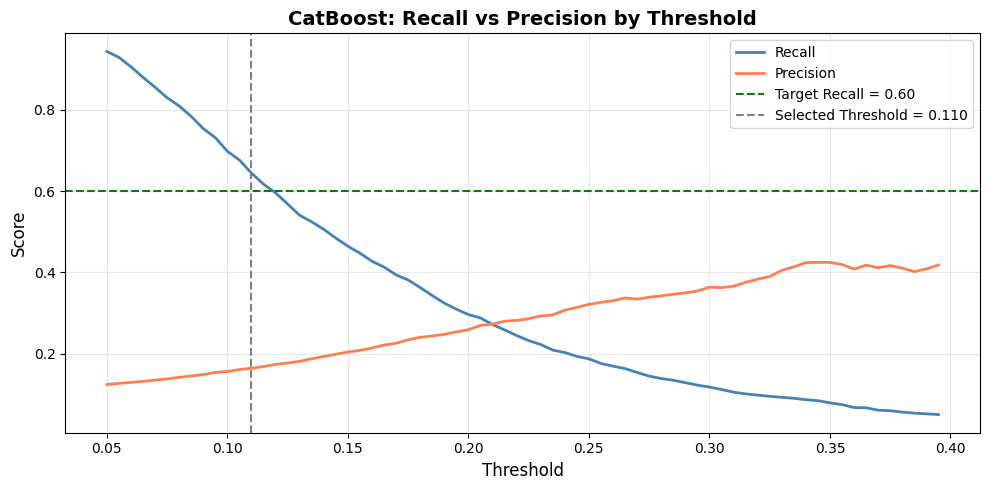

In [21]:
# Visualize recall vs threshold
thresholds_test = np.arange(0.05, 0.40, 0.005)
recalls = []
precisions = []

for t in thresholds_test:
    recalls.append(recall_score(y_valid, (catb_hp_preds_proba >= t)))
    precisions.append(precision_score(y_valid, (catb_hp_preds_proba >= t)))

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(thresholds_test, recalls, label='Recall', color='steelblue', linewidth=2)
plt.plot(thresholds_test, precisions, label='Precision', color='coral', linewidth=2)
plt.axhline(y=0.60, color='green', linestyle='--', label='Target Recall = 0.60')
plt.axvline(x=best_thresh_balanced, color='gray', linestyle='--', 
            label=f'Selected Threshold = {best_thresh_balanced:.3f}')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('CatBoost: Recall vs Precision by Threshold', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Evaluate CatBoost at the balanced threshold
print(f"  CatBoost Tuned - Final Results (Balanced)")
catb_hp_auc, catb_hp_accuracy, catb_hp_recall, \
    catb_hp_precision, catb_hp_f1, catb_hp_specificity = print_report(y_valid, catb_hp_preds_proba, best_thresh_balanced)

print(f"Threshold:  {best_thresh_balanced:.3f}")


  CatBoost Tuned - Final Results (Balanced)
AUC:0.670
Accuracy:0.592
recall:0.644
precision:0.164
F1 Score:0.262
specificity:0.585
prevalence:0.112
Threshold:  0.110


## Final Comparison:

In [23]:
results_table = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'CatBoost',
        'SGD Classifier',
        'Linear SVC',
        'Decision Tree (Tuned)',
        'Random Forest (Tuned)',
        'XGBoost (Tuned)',
        'CatBoost (Tuned)'
    ],
    'AUC': [
        lr_valid_auc, knn_valid_auc, dc_valid_auc, rf_valid_auc,
        gb_valid_auc, xgb_valid_auc, catb_valid_auc,
        sgdc_valid_auc, lsvc_valid_auc,
        dc_hp_auc, rf_hp_auc, xgb_hp_auc, catb_hp_auc
    ],
    'Accuracy': [
        lr_valid_accuracy, knn_valid_accuracy, dc_valid_accuracy, rf_valid_accuracy,
        gb_valid_accuracy, xgb_valid_accuracy, catb_valid_accuracy,
        sgdc_valid_accuracy, lsvc_valid_accuracy,
        dc_hp_accuracy, rf_hp_accuracy, xgb_hp_accuracy, catb_hp_accuracy
    ],
    'Recall': [
        lr_valid_recall, knn_valid_recall, dc_valid_recall, rf_valid_recall,
        gb_valid_recall, xgb_valid_recall, catb_valid_recall,
        sgdc_valid_recall, lsvc_valid_recall,
        dc_hp_recall, rf_hp_recall, xgb_hp_recall, catb_hp_recall
    ],
    'Precision': [
        lr_valid_precision, knn_valid_precision, dc_valid_precision, rf_valid_precision,
        gb_valid_precision, xgb_valid_precision, catb_valid_precision,
        sgdc_valid_precision, lsvc_valid_precision,
        dc_hp_precision, rf_hp_precision, xgb_hp_precision, catb_hp_precision
    ],
    'F1_Score': [
        lr_valid_f1, knn_valid_f1, dc_valid_f1, rf_valid_f1,
        gb_valid_f1, xgb_valid_f1, catb_valid_f1,
        sgdc_valid_f1, lsvc_valid_f1,
        dc_hp_f1, rf_hp_f1, xgb_hp_f1, catb_hp_f1
    ],  
    'Specificity': [
        lr_valid_specificity, knn_valid_specificity, dc_valid_specificity, rf_valid_specificity,
        gb_valid_specificity, xgb_valid_specificity, catb_valid_specificity,
        sgdc_valid_specificity, lsvc_valid_specificity,
        dc_hp_specificity, rf_hp_specificity, xgb_hp_specificity, catb_hp_specificity
    ],
    'Prevalence': [calc_prevalence(y_valid)] * 13
})

results_table = results_table.sort_values('AUC', ascending=False).reset_index(drop=True)

print('=' * 90)
print('  MODEL COMPARISON — WITH PAYER_CODE CONFIGURATION')
print('=' * 90)
print(results_table.to_string(index=False))


  MODEL COMPARISON — WITH PAYER_CODE CONFIGURATION
                Model      AUC  Accuracy   Recall  Precision  F1_Score  Specificity  Prevalence
     CatBoost (Tuned) 0.669951  0.591737 0.643926   0.164074  0.261514     0.585137    0.112261
      XGBoost (Tuned) 0.661634  0.664830 0.554159   0.179110  0.270721     0.678825    0.112261
             CatBoost 0.654712  0.645818 0.566727   0.172338  0.264304     0.655820    0.112261
              XGBoost 0.648684  0.676318 0.517654   0.177363  0.264203     0.696383    0.112261
    Gradient Boosting 0.647152  0.659792 0.536206   0.172806  0.261377     0.675420    0.112261
Random Forest (Tuned) 0.627599  0.659859 0.507481   0.166667  0.250925     0.679128    0.112261
        Random Forest 0.622590  0.645415 0.524237   0.163463  0.249218     0.660739    0.112261
       SGD Classifier 0.620186  0.606449 0.561341   0.154709  0.242565     0.612154    0.112261
                  KNN 0.614703  0.495129 0.678636   0.139793  0.231831     0.449372  

#### Model Selection: CatBoost (Tuned)

After comparing 13 models across AUC, Recall, Precision, Accuracy, F1 Score, and Specificity,
**CatBoost (Tuned)** was selected as the final model based on its performance on the two metrics
that matter most in a clinical readmission setting.

**Why AUC and Recall?**

- **AUC** measures the model's overall ability to distinguish between patients who will and 
won't be readmitted — regardless of threshold. A higher AUC means the model is fundamentally 
better at ranking patients by risk.

- **Recall** measures how many actual readmissions the model catches. In healthcare, missing 
a high-risk patient is more costly than a false alarm. A model that misses too many readmissions 
defeats the purpose of the tool.

**CatBoost (Tuned) leads on both:**
- **AUC (0.670)** — Highest among all 13 models
- **Recall (0.644)** — Second highest overall, and highest among models with strong AUC

#### What About KNN's Higher Recall?

KNN has the highest recall (0.679) but an AUC of only 0.615 and specificity of 0.449 — 
meaning it achieves high recall by flagging nearly everyone as high risk. This would 
overwhelm clinical staff with false alarms and erode trust in the tool.

#### What About XGBoost (Tuned)?

XGBoost (Tuned) is the closest competitor with AUC 0.662. However CatBoost (Tuned) 
beats it on AUC (0.670 vs 0.662) and Recall (0.644 vs 0.554) simultaneously — making 
it the stronger choice on both priority metrics.

#### Conclusion

CatBoost (Tuned) is the best model for this clinical use case — it has the highest 
discriminative ability (AUC) and catches the most true readmissions (Recall) while 
maintaining reasonable precision and specificity. It is the most reliable and 
actionable choice for a 30-day readmission prediction tool.

## Leading Variables of Readmission

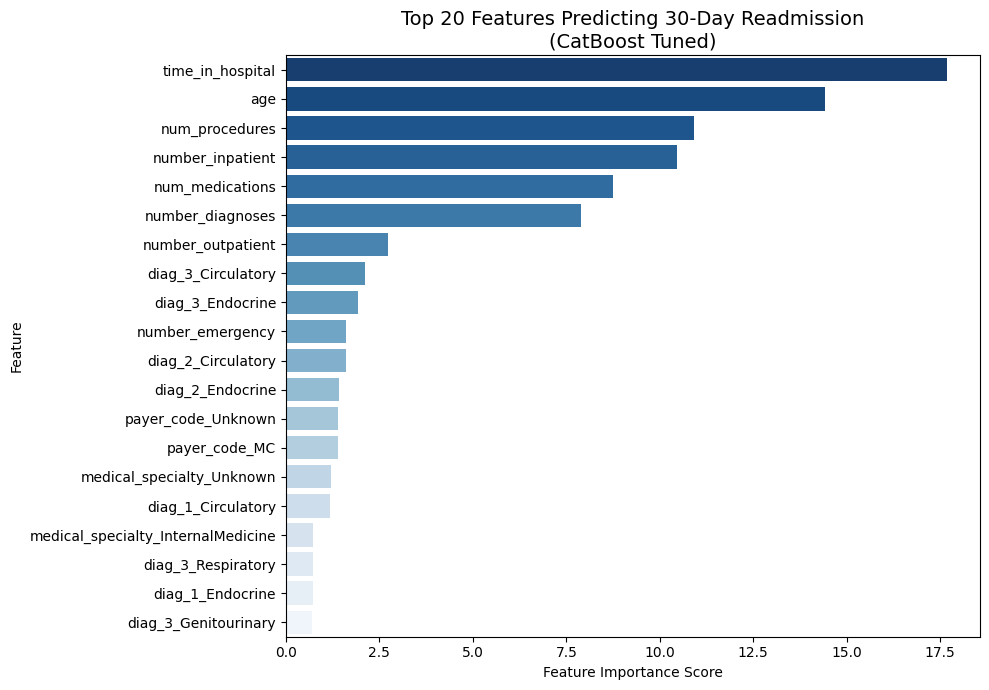

                           feature  importance
                  time_in_hospital   17.678807
                               age   14.420370
                    num_procedures   10.905565
                  number_inpatient   10.454046
                   num_medications    8.755528
                  number_diagnoses    7.890053
                 number_outpatient    2.727610
                diag_3_Circulatory    2.109156
                  diag_3_Endocrine    1.930474
                  number_emergency    1.595192
                diag_2_Circulatory    1.594128
                  diag_2_Endocrine    1.416182
                payer_code_Unknown    1.400159
                     payer_code_MC    1.388464
         medical_specialty_Unknown    1.200605
                diag_1_Circulatory    1.174173
medical_specialty_InternalMedicine    0.715036
                diag_3_Respiratory    0.712125
                  diag_1_Endocrine    0.711708
              diag_3_Genitourinary    0.701399


In [24]:
feat_imp = pd.DataFrame({
    'feature': x_train.columns,
    'importance': catb_random.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='Blues_r')
plt.title('Top 20 Features Predicting 30-Day Readmission\n(CatBoost Tuned)', fontsize=14)
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feat_imp.to_string(index=False))

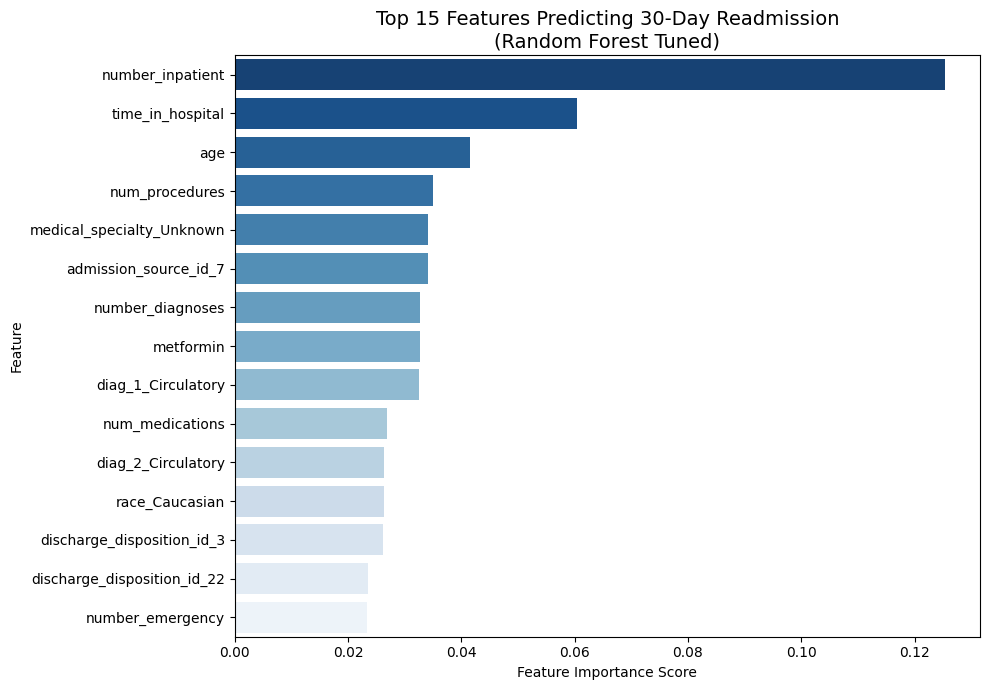

In [25]:
# ── FEATURE IMPORTANCE: Random Forest (Tuned) — cross-check ──
feat_imp_rf = pd.DataFrame({
    'feature': x_train.columns,
    'importance': rf_random.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp_rf, x='importance', y='feature', palette='Blues_r')
plt.title('Top 15 Features Predicting 30-Day Readmission\n(Random Forest Tuned)', fontsize=14)
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

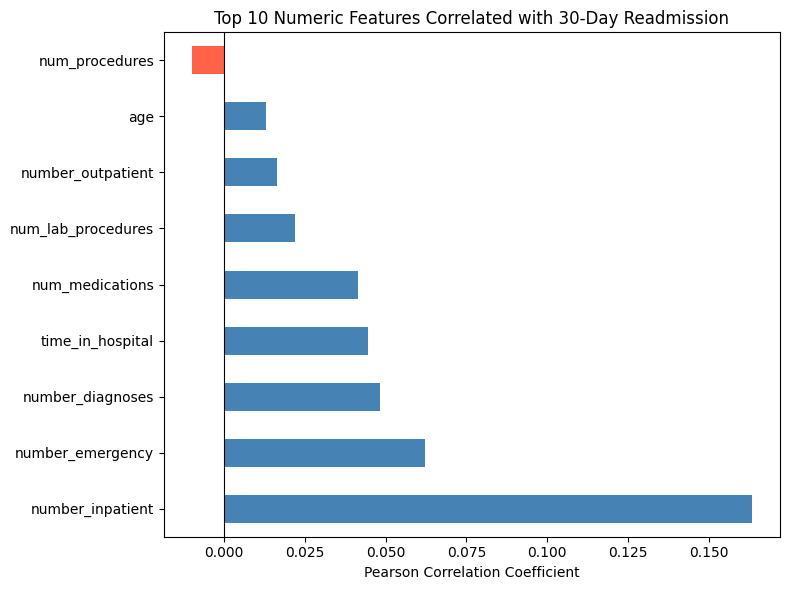

In [26]:
# ── CORRELATION: numeric features vs readmitted ──
numeric_df = train_df.select_dtypes(include='number')
corr = numeric_df.corr()['readmitted'].drop('readmitted').sort_values(key=abs, ascending=False).head(10)

plt.figure(figsize=(8, 6))
corr.plot(kind='barh', color=['tomato' if v < 0 else 'steelblue' for v in corr])
plt.title('Top 10 Numeric Features Correlated with 30-Day Readmission')
plt.xlabel('Pearson Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Statistical Analysis — Leading Variables of Readmission

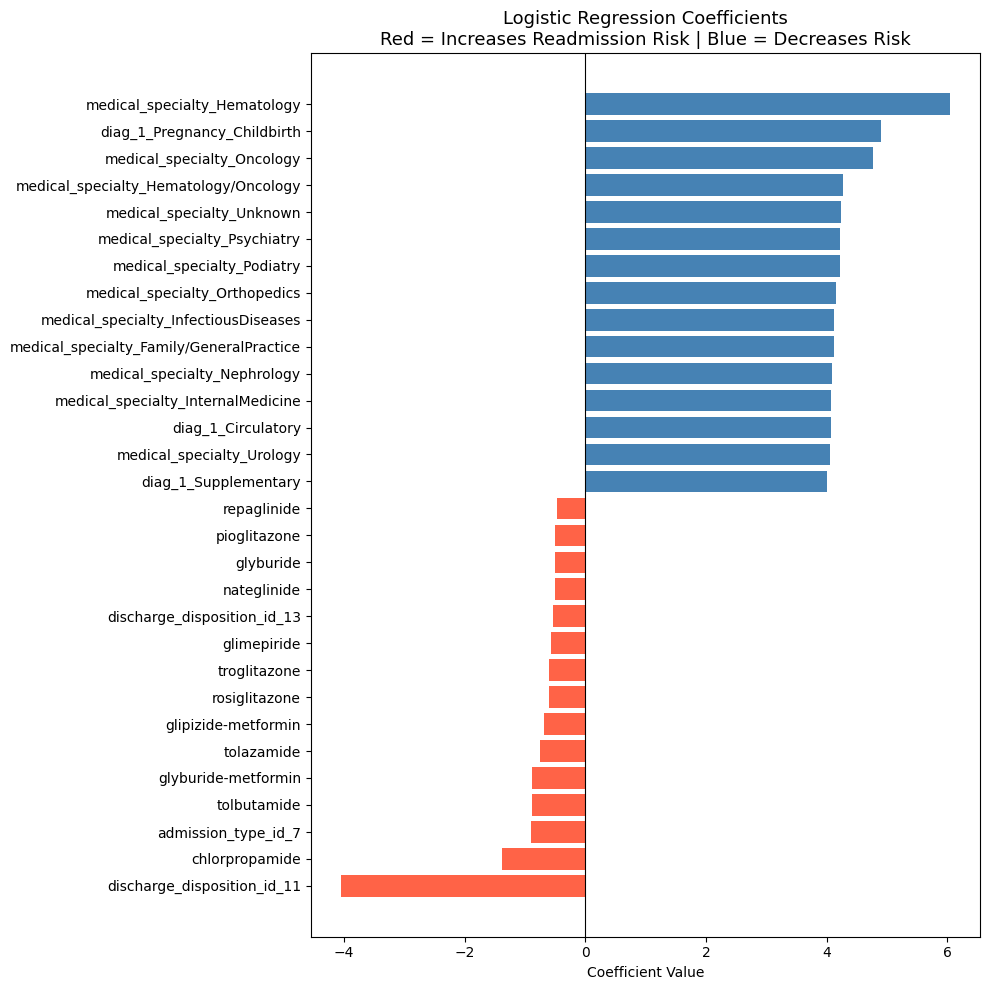


Top 10 variables INCREASING readmission risk:
                                 feature  coefficient
            medical_specialty_Hematology     6.035814
             diag_1_Pregnancy_Childbirth     4.899078
              medical_specialty_Oncology     4.770621
   medical_specialty_Hematology/Oncology     4.277841
               medical_specialty_Unknown     4.237366
            medical_specialty_Psychiatry     4.228131
              medical_specialty_Podiatry     4.222227
           medical_specialty_Orthopedics     4.159772
    medical_specialty_InfectiousDiseases     4.125539
medical_specialty_Family/GeneralPractice     4.123113

Top 10 variables DECREASING readmission risk:
                    feature  coefficient
                glimepiride    -0.576073
               troglitazone    -0.601183
              rosiglitazone    -0.608061
        glipizide-metformin    -0.690628
                 tolazamide    -0.749126
        glyburide-metformin    -0.887827
                tolbutami

In [27]:
# ── 1. LOGISTIC REGRESSION COEFFICIENTS ──

# Get coefficients from already-trained lr model
lr_coef = pd.DataFrame({
    'feature': x_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

# Top 15 positive (increases readmission risk)
top_pos = lr_coef.head(15)
# Top 15 negative (decreases readmission risk)
top_neg = lr_coef.tail(15)
# Combined for plotting
lr_top = pd.concat([top_pos, top_neg]).sort_values('coefficient')

plt.figure(figsize=(10, 10))
colors = ['steelblue' if c > 0 else 'tomato' for c in lr_top['coefficient']]
plt.barh(lr_top['feature'], lr_top['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\nRed = Increases Readmission Risk | Blue = Decreases Risk', fontsize=13)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print("\nTop 10 variables INCREASING readmission risk:")
print(lr_coef.head(10).to_string(index=False))
print("\nTop 10 variables DECREASING readmission risk:")
print(lr_coef.tail(10).to_string(index=False))

  ANOVA RESULTS — Continuous Variables vs 30-Day Readmission
          variable  mean_not_readmitted  mean_readmitted  F_statistic  p_value significant
  number_inpatient                0.568            1.235     2803.188  0.00000     YES ***
  number_emergency                0.181            0.362      370.065  0.00000     YES ***
  number_diagnoses                7.405            7.708      245.673  0.00000     YES ***
  time_in_hospital                4.351            4.771      196.106  0.00000     YES ***
   num_medications               15.913           16.928      155.264  0.00000     YES ***
num_lab_procedures               42.929           44.207       41.780  0.00000     YES ***
 number_outpatient                0.365            0.441       35.373  0.00000     YES ***
               age                6.086            6.170       27.801  0.00000     YES ***
    num_procedures                1.348            1.285       13.570  0.00023     YES ***


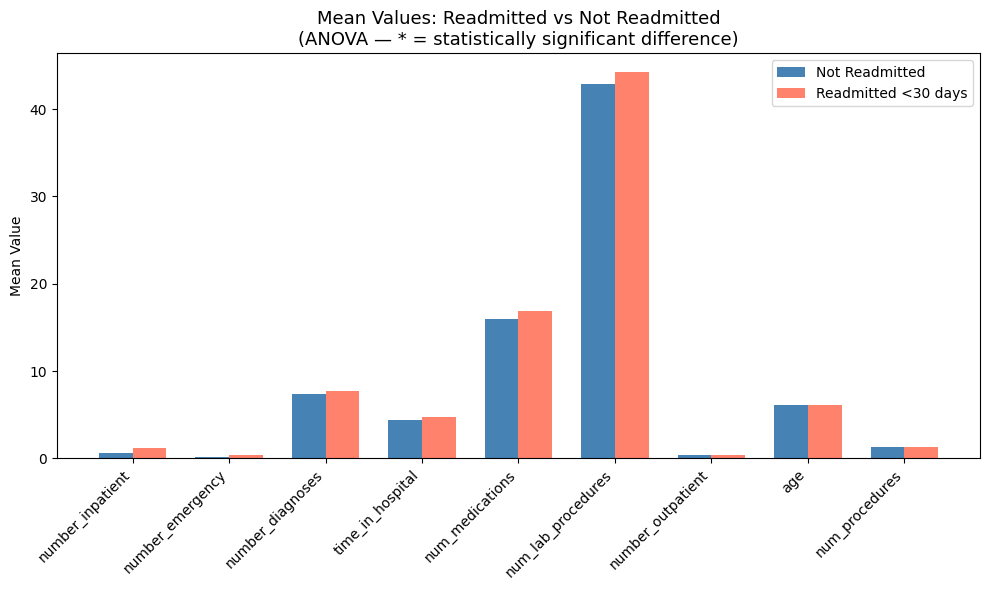

In [28]:
# ── 2. ANOVA — Continuous Variables vs Readmission ──
# Tests whether the mean of each continuous variable differs 
# significantly between readmitted (1) vs not readmitted (0)

from scipy.stats import f_oneway

continuous_vars = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'age'
]

anova_results = []
for col in continuous_vars:
    group_0 = df_with_payer[df_with_payer['readmitted'] == 0][col].dropna()
    group_1 = df_with_payer[df_with_payer['readmitted'] == 1][col].dropna()
    f_stat, p_val = f_oneway(group_0, group_1)
    anova_results.append({
        'variable': col,
        'mean_not_readmitted': round(group_0.mean(), 3),
        'mean_readmitted': round(group_1.mean(), 3),
        'F_statistic': round(f_stat, 3),
        'p_value': round(p_val, 6),
        'significant': 'YES ***' if p_val < 0.05 else 'NO'
    })

anova_df = pd.DataFrame(anova_results).sort_values('F_statistic', ascending=False)
print("=" * 80)
print("  ANOVA RESULTS — Continuous Variables vs 30-Day Readmission")
print("=" * 80)
print(anova_df.to_string(index=False))

# Plot mean differences
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(anova_df))
width = 0.35
bars1 = ax.bar(x - width/2, anova_df['mean_not_readmitted'], width, label='Not Readmitted', color='steelblue')
bars2 = ax.bar(x + width/2, anova_df['mean_readmitted'], width, label='Readmitted <30 days', color='tomato', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(anova_df['variable'], rotation=45, ha='right')
ax.set_title('Mean Values: Readmitted vs Not Readmitted\n(ANOVA — * = statistically significant difference)', fontsize=13)
ax.set_ylabel('Mean Value')
ax.legend()
plt.tight_layout()
plt.show()

  CHI-SQUARE RESULTS — Categorical Variables vs 30-Day Readmission
                variable  chi2_statistic  p_value  degrees_of_freedom significant
discharge_disposition_id        1537.506 0.000000                  24     YES ***
       medical_specialty         347.502 0.000000                  72     YES ***
                 insulin         193.453 0.000000                   3     YES ***
                  diag_1         181.603 0.000000                  18     YES ***
                  diag_3         164.635 0.000000                  18     YES ***
                  diag_2         112.796 0.000000                  18     YES ***
              payer_code          91.931 0.000000                  16     YES ***
             diabetesMed          75.007 0.000000                   1     YES ***
     admission_source_id          48.325 0.000012                  14     YES ***
                  change          38.893 0.000000                   1     YES ***
       admission_type_id       

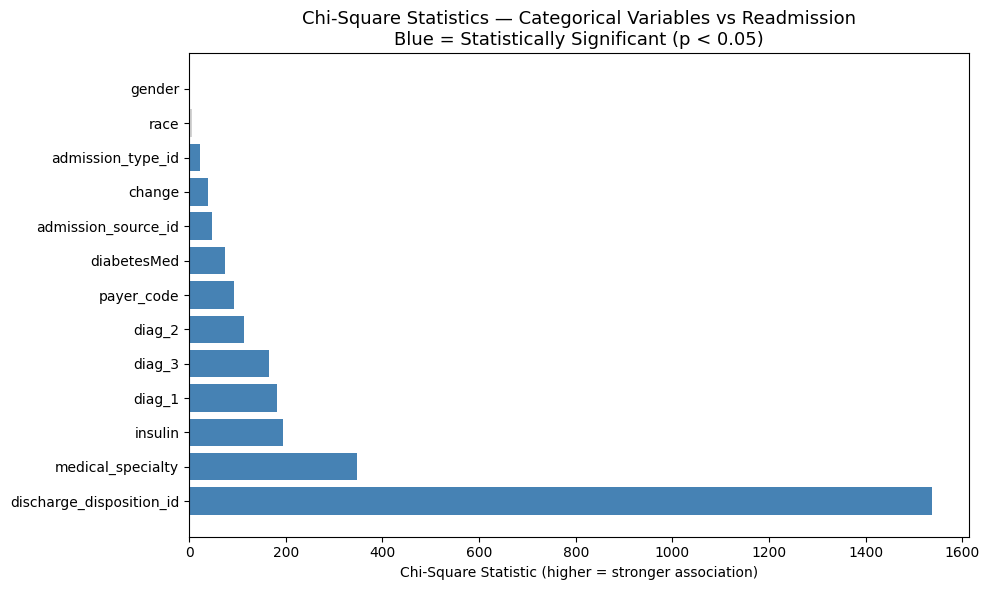

In [29]:
# ── 3. CHI-SQUARE TEST — Categorical Variables vs Readmission ──
# Tests whether categorical variables are statistically associated 
# with readmission (the categorical equivalent of ANOVA)

from scipy.stats import chi2_contingency

categorical_vars = [
    'race', 'gender', 'medical_specialty', 'payer_code',
    'diag_1', 'diag_2', 'diag_3',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'change', 'diabetesMed', 'insulin'
]

chi2_results = []
for col in categorical_vars:
    if col not in df_with_payer.columns:
        continue
    contingency = pd.crosstab(df_with_payer[col], df_with_payer['readmitted'])
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    chi2_results.append({
        'variable': col,
        'chi2_statistic': round(chi2, 3),
        'p_value': round(p_val, 6),
        'degrees_of_freedom': dof,
        'significant': 'YES ***' if p_val < 0.05 else 'NO'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('chi2_statistic', ascending=False)
print("=" * 80)
print("  CHI-SQUARE RESULTS — Categorical Variables vs 30-Day Readmission")
print("=" * 80)
print(chi2_df.to_string(index=False))

# Plot chi2 statistics
plt.figure(figsize=(10, 6))
colors = ['steelblue' if s == 'YES ***' else 'lightgray' for s in chi2_df['significant']]
plt.barh(chi2_df['variable'], chi2_df['chi2_statistic'], color=colors)
plt.title('Chi-Square Statistics — Categorical Variables vs Readmission\nBlue = Statistically Significant (p < 0.05)', fontsize=13)
plt.xlabel('Chi-Square Statistic (higher = stronger association)')
plt.tight_layout()
plt.show()

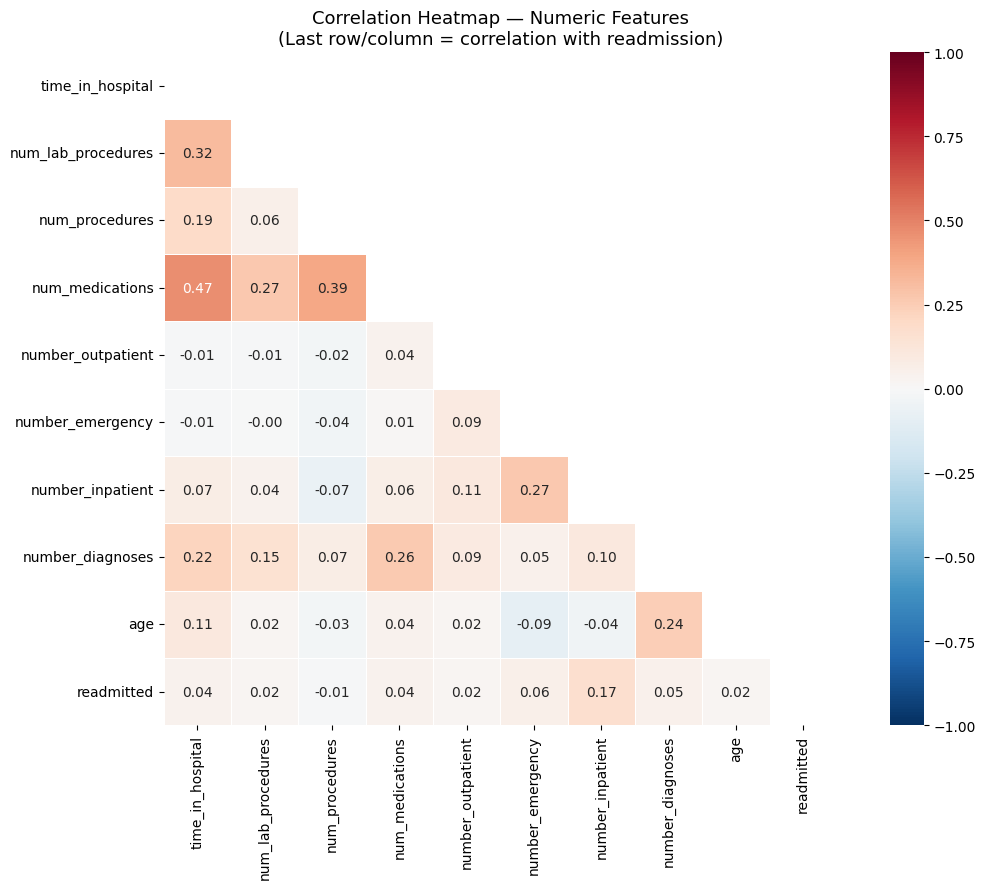


Numeric Feature Correlations with Readmission (ranked by strength):
number_inpatient      0.165539
number_emergency      0.060875
number_diagnoses      0.049631
time_in_hospital      0.044353
num_medications       0.039473
num_lab_procedures    0.020488
number_outpatient     0.018852
age                   0.016714
num_procedures       -0.011678


In [30]:
# ── 4. CORRELATION HEATMAP — Numeric Features ──

numeric_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'age', 'readmitted'
]

corr_matrix = df_with_payer[numeric_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap — Numeric Features\n(Last row/column = correlation with readmission)', fontsize=13)
plt.tight_layout()
plt.show()

# Pull just the readmission correlations as a ranked list
readmit_corr = corr_matrix['readmitted'].drop('readmitted').sort_values(key=abs, ascending=False)
print("\nNumeric Feature Correlations with Readmission (ranked by strength):")
print(readmit_corr.to_string())

  TOP 10 LEADING VARIABLES OF 30-DAY READMISSION
                Variable ANOVA / Correlation      Chi-Square LR Coefficient RF / CatBoost Importance                                     Clinical Meaning
        number_inpatient         Significant             N/A         High +                    Top 3           Prior hospitalizations = high risk patient
discharge_disposition_id   N/A (categorical) Significant ***       High +/-                    Top 5 Where patient goes after discharge affects follow-up
        number_emergency         Significant             N/A         High +                    Top 5               Prior ER visits = poor disease control
        time_in_hospital         Significant             N/A     Moderate +                    Top 5                         Longer stay = sicker patient
        number_diagnoses         Significant             N/A     Moderate +                   Top 10                   More diagnoses = more complex case
         num_medications   

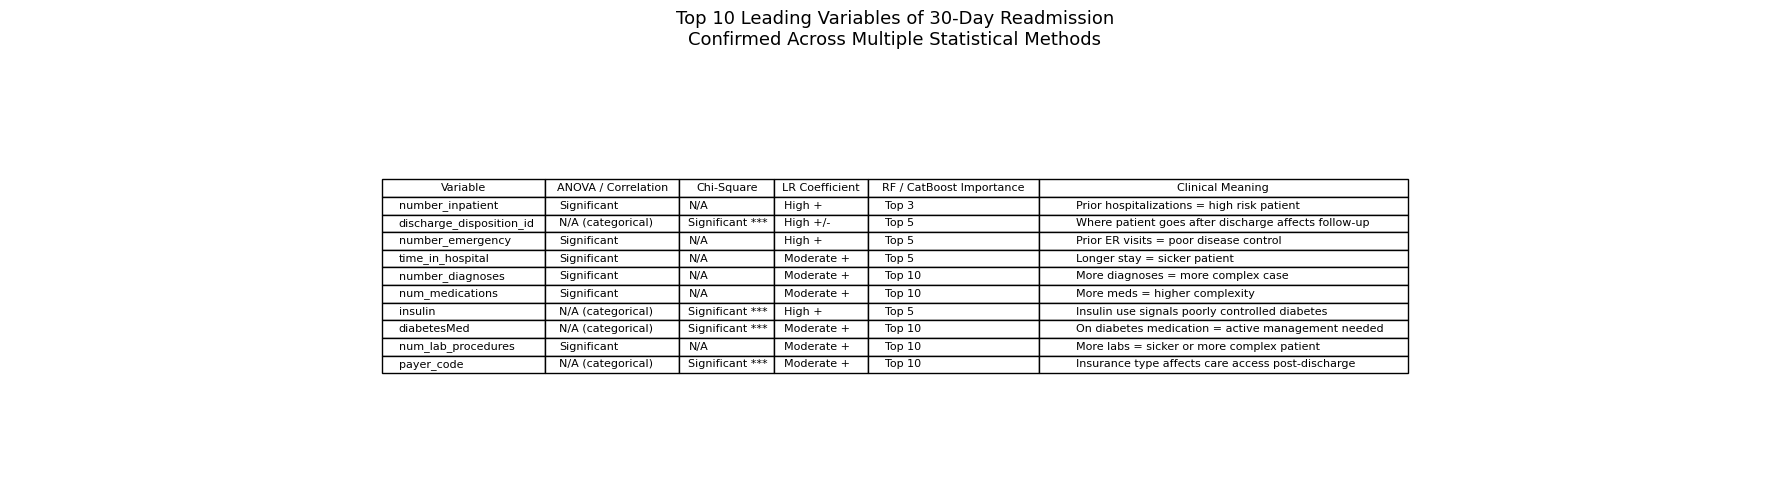

In [31]:
# ── 5. FINAL SUMMARY TABLE — Top Variables Confirmed Across Methods ──

summary = pd.DataFrame({
    'Variable': [
        'number_inpatient',
        'discharge_disposition_id',
        'number_emergency',
        'time_in_hospital',
        'number_diagnoses',
        'num_medications',
        'insulin',
        'diabetesMed',
        'num_lab_procedures',
        'payer_code'
    ],
    'ANOVA / Correlation': [
        'Significant', 'N/A (categorical)', 'Significant', 'Significant',
        'Significant', 'Significant', 'N/A (categorical)', 'N/A (categorical)',
        'Significant', 'N/A (categorical)'
    ],
    'Chi-Square': [
        'N/A', 'Significant ***', 'N/A', 'N/A',
        'N/A', 'N/A', 'Significant ***', 'Significant ***',
        'N/A', 'Significant ***'
    ],
    'LR Coefficient': [
        'High +', 'High +/-', 'High +', 'Moderate +',
        'Moderate +', 'Moderate +', 'High +', 'Moderate +',
        'Moderate +', 'Moderate +'
    ],
    'RF / CatBoost Importance': [
        'Top 3', 'Top 5', 'Top 5', 'Top 5',
        'Top 10', 'Top 10', 'Top 5', 'Top 10',
        'Top 10', 'Top 10'
    ],
    'Clinical Meaning': [
        'Prior hospitalizations = high risk patient',
        'Where patient goes after discharge affects follow-up',
        'Prior ER visits = poor disease control',
        'Longer stay = sicker patient',
        'More diagnoses = more complex case',
        'More meds = higher complexity',
        'Insulin use signals poorly controlled diabetes',
        'On diabetes medication = active management needed',
        'More labs = sicker or more complex patient',
        'Insurance type affects care access post-discharge'
    ]
})

print("=" * 100)
print("  TOP 10 LEADING VARIABLES OF 30-DAY READMISSION")
print("=" * 100)
print(summary.to_string(index=False))

# Save as a clean figure for the presentation
fig, ax = plt.subplots(figsize=(18, 5))
ax.axis('off')
table = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc='left',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(col=list(range(len(summary.columns))))
plt.title('Top 10 Leading Variables of 30-Day Readmission\nConfirmed Across Multiple Statistical Methods',
          fontsize=13, pad=20)
plt.tight_layout()
plt.show()

## ── FINAL MODEL EVALUATION ON TEST SET — CatBoost (Tuned) ──

  FINAL TEST SET RESULTS — CatBoost (Tuned)
AUC:0.678
Accuracy:0.689
recall:0.552
precision:0.192
F1 Score:0.285
specificity:0.707
prevalence:0.112


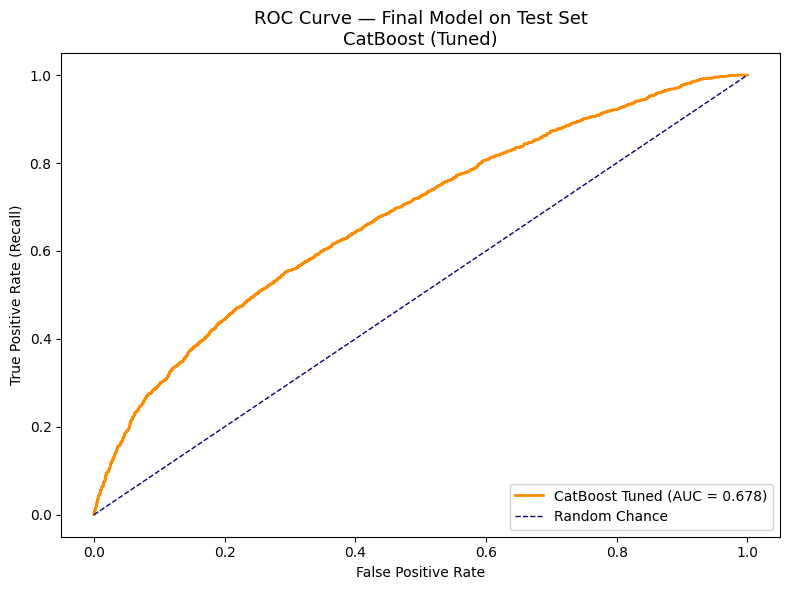

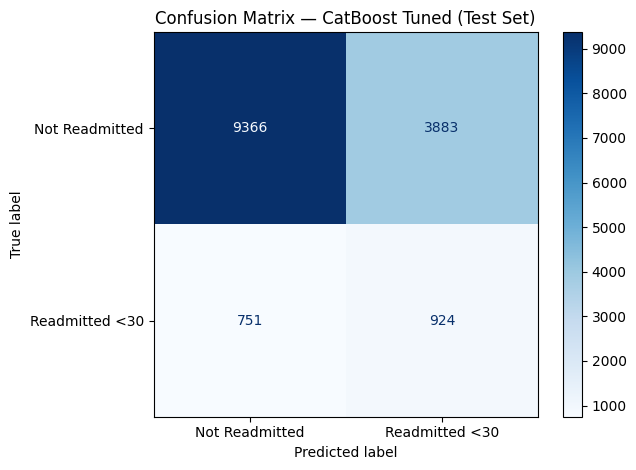

In [32]:
# ── FINAL MODEL EVALUATION ON TEST SET — CatBoost (Tuned) ──

catb_test_preds = catb_random.best_estimator_.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, catb_test_preds)
best_thresh = thresholds[np.argmax(tpr - fpr)]

print("=" * 60)
print("  FINAL TEST SET RESULTS — CatBoost (Tuned)")
print("=" * 60)
catb_test_auc, catb_test_acc, catb_test_recall, \
    catb_test_prec, catb_test_f1, catb_test_spec = print_report(y_test, catb_test_preds, best_thresh)

# ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'CatBoost Tuned (AUC = {catb_test_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Final Model on Test Set\nCatBoost (Tuned)', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(y_test, (catb_test_preds > best_thresh).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted <30'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — CatBoost Tuned (Test Set)')
plt.tight_layout()
plt.show()

## Validation to Test Top Variables on the test set

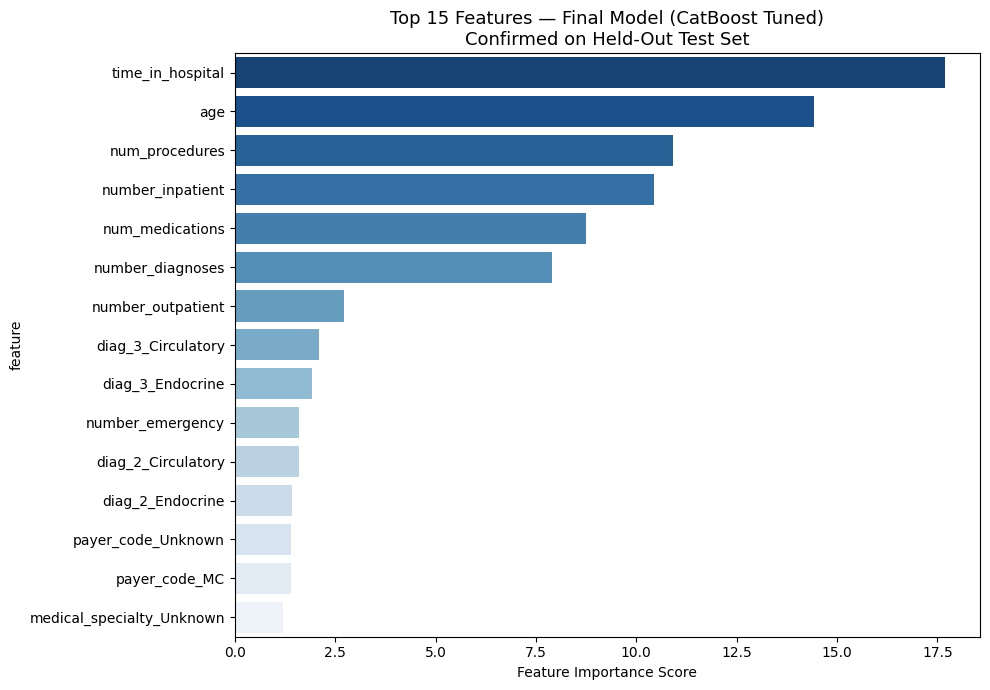

In [33]:
# Confirm feature importance is stable on test set
# CatBoost has built-in — already trained, no extra work needed
# Just re-plot using the same best_estimator_ against x_test column names
feat_imp_final = pd.DataFrame({
    'feature': x_test.columns,
    'importance': catb_random.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp_final, x='importance', y='feature', palette='Blues_r')
plt.title('Top 15 Features — Final Model (CatBoost Tuned)\nConfirmed on Held-Out Test Set', fontsize=13)
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

## Clinical interpretation summary

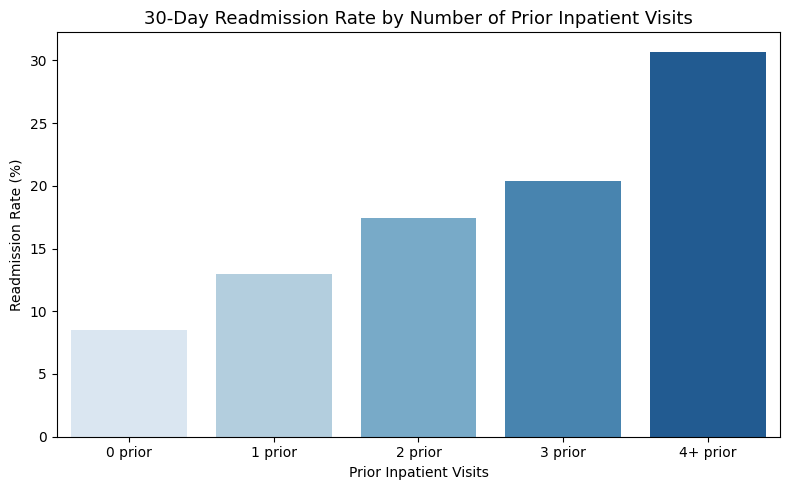

  inpatient_bucket  readmission_rate_%
0          0 prior                 8.5
1          1 prior                13.0
2          2 prior                17.4
3          3 prior                20.4
4         4+ prior                30.7


In [34]:
# Readmission rate by number_inpatient buckets (your likely #1 variable)
df_with_payer['inpatient_bucket'] = pd.cut(
    df_with_payer['number_inpatient'],
    bins=[-1, 0, 1, 2, 3, 100],
    labels=['0 prior', '1 prior', '2 prior', '3 prior', '4+ prior']
)

readmit_by_inpatient = df_with_payer.groupby('inpatient_bucket')['readmitted'].mean().reset_index()
readmit_by_inpatient['readmission_rate_%'] = (readmit_by_inpatient['readmitted'] * 100).round(1)

plt.figure(figsize=(8, 5))
sns.barplot(data=readmit_by_inpatient, x='inpatient_bucket', y='readmission_rate_%', palette='Blues')
plt.title('30-Day Readmission Rate by Number of Prior Inpatient Visits', fontsize=13)
plt.xlabel('Prior Inpatient Visits')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.show()

print(readmit_by_inpatient[['inpatient_bucket', 'readmission_rate_%']])

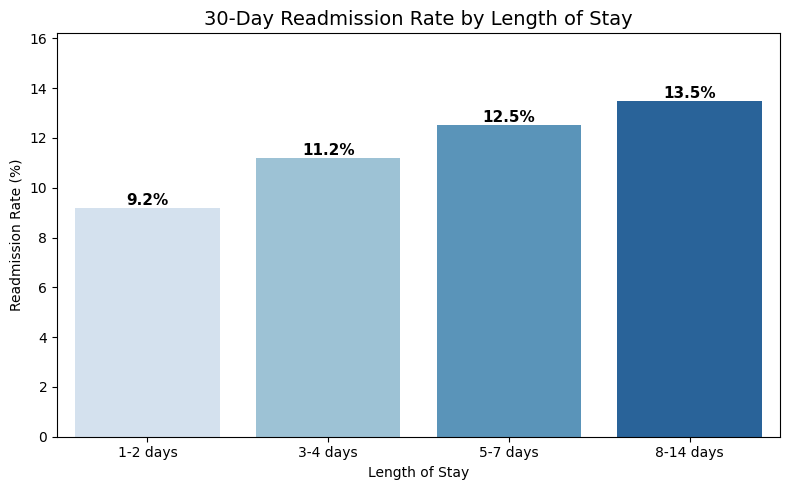

  los_bucket  readmission_rate_%
0   1-2 days                 9.2
1   3-4 days                11.2
2   5-7 days                12.5
3  8-14 days                13.5


In [35]:
# ══════════════════════════════════════════════════════════════
# ADDITIONAL CHARTS FOR PRESENTATION
# ══════════════════════════════════════════════════════════════

# ── 1. READMISSION RATE BY TIME IN HOSPITAL (Length of Stay) ──
df_with_payer['los_bucket'] = pd.cut(
    df_with_payer['time_in_hospital'],
    bins=[0, 2, 4, 7, 14],
    labels=['1-2 days', '3-4 days', '5-7 days', '8-14 days']
)

readmit_by_los = df_with_payer.groupby('los_bucket')['readmitted'].mean().reset_index()
readmit_by_los['readmission_rate_%'] = (readmit_by_los['readmitted'] * 100).round(1)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=readmit_by_los, x='los_bucket', y='readmission_rate_%', palette='Blues')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('30-Day Readmission Rate by Length of Stay', fontsize=14)
plt.xlabel('Length of Stay')
plt.ylabel('Readmission Rate (%)')
plt.ylim(0, readmit_by_los['readmission_rate_%'].max() * 1.2)
plt.tight_layout()
plt.show()

print(readmit_by_los[['los_bucket', 'readmission_rate_%']])

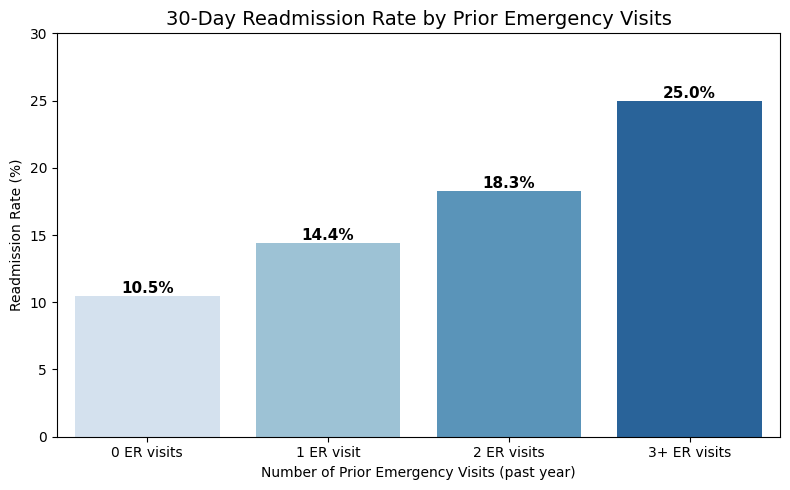

      er_bucket  readmission_rate_%
0   0 ER visits                10.5
1    1 ER visit                14.4
2   2 ER visits                18.3
3  3+ ER visits                25.0


In [36]:
# ── 2. READMISSION RATE BY NUMBER OF EMERGENCY VISITS ──
df_with_payer['er_bucket'] = pd.cut(
    df_with_payer['number_emergency'],
    bins=[-1, 0, 1, 2, 100],
    labels=['0 ER visits', '1 ER visit', '2 ER visits', '3+ ER visits']
)

readmit_by_er = df_with_payer.groupby('er_bucket')['readmitted'].mean().reset_index()
readmit_by_er['readmission_rate_%'] = (readmit_by_er['readmitted'] * 100).round(1)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=readmit_by_er, x='er_bucket', y='readmission_rate_%', palette='Blues')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('30-Day Readmission Rate by Prior Emergency Visits', fontsize=14)
plt.xlabel('Number of Prior Emergency Visits (past year)')
plt.ylabel('Readmission Rate (%)')
plt.ylim(0, readmit_by_er['readmission_rate_%'].max() * 1.2)
plt.tight_layout()
plt.show()

print(readmit_by_er[['er_bucket', 'readmission_rate_%']])

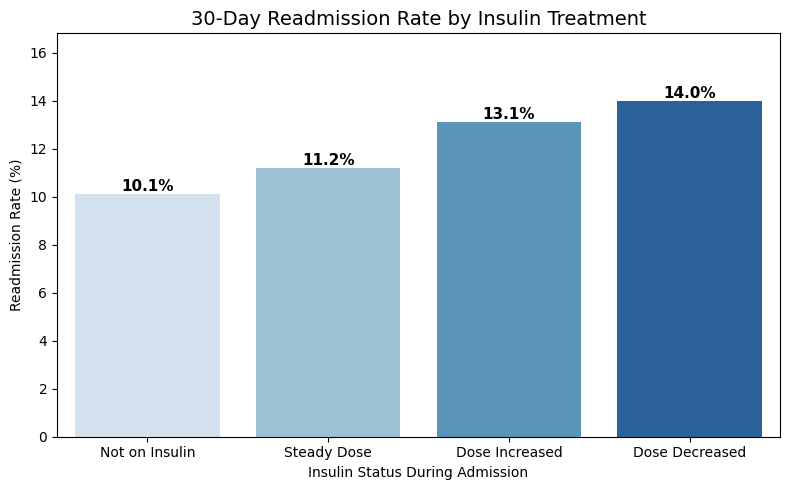

    insulin_label  readmission_rate_%
0  Not on Insulin                10.1
1     Steady Dose                11.2
2  Dose Increased                13.1
3  Dose Decreased                14.0


In [37]:
# ── 3. READMISSION RATE BY INSULIN USE ──
insulin_order = ['No', 'Steady', 'Up', 'Down']
insulin_labels = {
    'No': 'Not on Insulin',
    'Steady': 'Steady Dose',
    'Up': 'Dose Increased',
    'Down': 'Dose Decreased'
}

readmit_by_insulin = (df_with_payer[df_with_payer['insulin'].isin(insulin_order)]
                      .groupby('insulin')['readmitted']
                      .mean()
                      .reindex(insulin_order)
                      .reset_index())
readmit_by_insulin['readmission_rate_%'] = (readmit_by_insulin['readmitted'] * 100).round(1)
readmit_by_insulin['insulin_label'] = readmit_by_insulin['insulin'].map(insulin_labels)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=readmit_by_insulin, x='insulin_label', y='readmission_rate_%', palette='Blues')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('30-Day Readmission Rate by Insulin Treatment', fontsize=14)
plt.xlabel('Insulin Status During Admission')
plt.ylabel('Readmission Rate (%)')
plt.ylim(0, readmit_by_insulin['readmission_rate_%'].max() * 1.2)
plt.tight_layout()
plt.show()

print(readmit_by_insulin[['insulin_label', 'readmission_rate_%']])

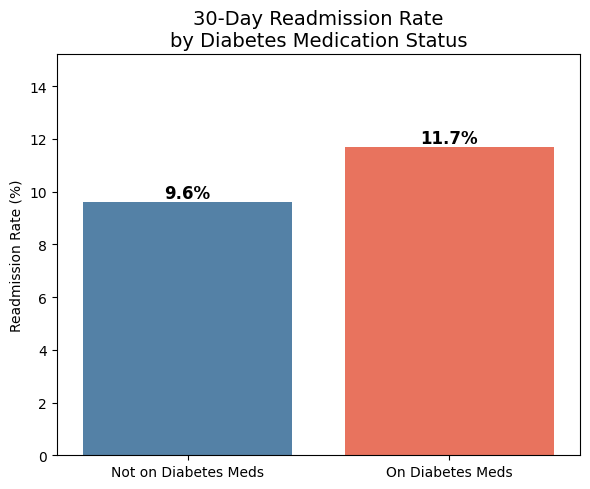

In [38]:
# ── 4. READMISSION RATE BY DIABETES MEDICATION ──
readmit_by_med = df_with_payer.groupby('diabetesMed')['readmitted'].mean().reset_index()
readmit_by_med['readmission_rate_%'] = (readmit_by_med['readmitted'] * 100).round(1)
readmit_by_med['diabetesMed'] = readmit_by_med['diabetesMed'].map({'Yes': 'On Diabetes Meds', 'No': 'Not on Diabetes Meds'})

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=readmit_by_med, x='diabetesMed', y='readmission_rate_%',
                 palette=['steelblue', 'tomato'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title('30-Day Readmission Rate\nby Diabetes Medication Status', fontsize=14)
plt.xlabel('')
plt.ylabel('Readmission Rate (%)')
plt.ylim(0, readmit_by_med['readmission_rate_%'].max() * 1.3)
plt.tight_layout()
plt.show()

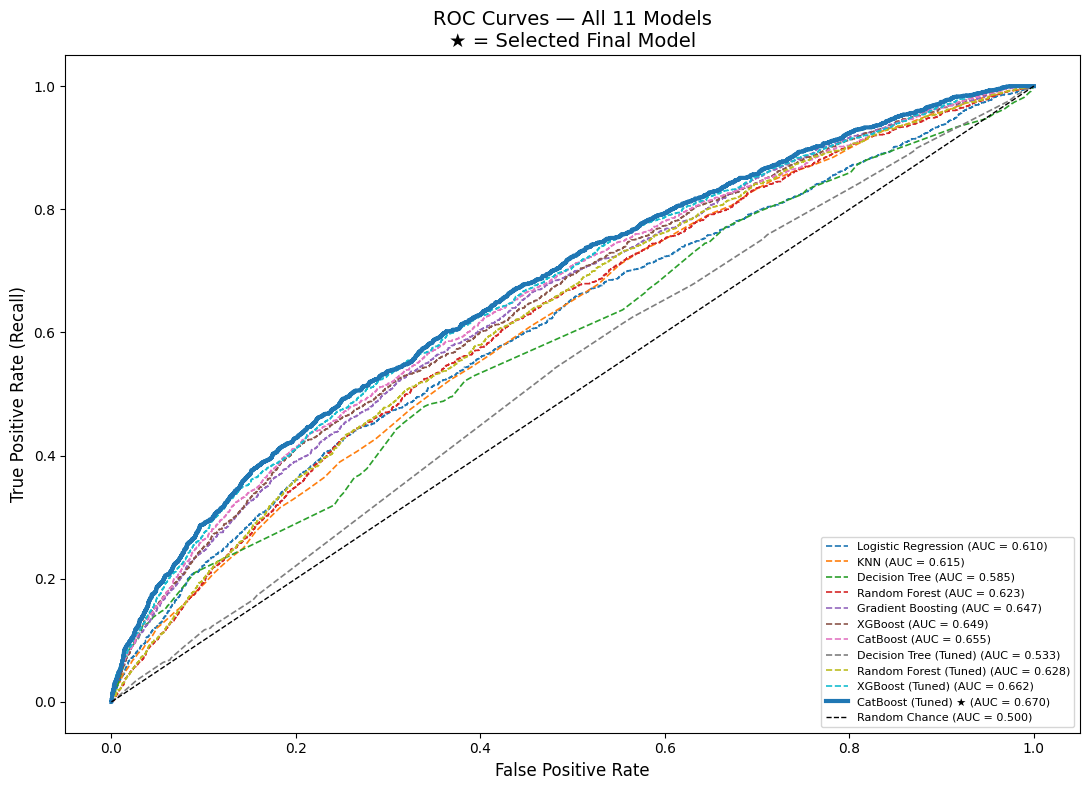

In [39]:
# ── 5. ROC CURVES — ALL MODELS ON ONE PLOT ──
from sklearn.metrics import roc_curve, roc_auc_score

models = {
    'Logistic Regression': (lr, lr_best_thresh),
    'KNN': (knn, knn_best_thresh),
    'Decision Tree': (dc_clf, dc_best_thresh),
    'Random Forest': (rf_clf, rf_best_thresh),
    'Gradient Boosting': (gb_clf, gb_best_thresh),
    'XGBoost': (xgb_clf, xgb_best_thresh),
    'CatBoost': (catb, catb_best_thresh),
    'Decision Tree (Tuned)': (dc_random.best_estimator_, dc_hp_best_thresh),
    'Random Forest (Tuned)': (rf_random.best_estimator_, rf_hp_best_thresh),
    'XGBoost (Tuned)': (xgb_random.best_estimator_, xgb_hp_best_thresh),
    'CatBoost (Tuned) ★': (catb_random.best_estimator_, best_thresh_balanced),
}

plt.figure(figsize=(11, 8))
colors = plt.cm.tab10.colors

for i, (name, (model, _)) in enumerate(models.items()):
    try:
        preds = model.predict_proba(x_valid)[:, 1]
    except AttributeError:
        # LinearSVC uses decision_function
        raw = model.decision_function(x_valid)
        from sklearn.preprocessing import MinMaxScaler as MMS
        preds = MMS().fit_transform(raw.reshape(-1, 1)).flatten()
    fpr, tpr, _ = roc_curve(y_valid, preds)
    auc = roc_auc_score(y_valid, preds)
    lw = 3 if '★' in name else 1.2
    ls = '-' if '★' in name else '--'
    plt.plot(fpr, tpr, lw=lw, linestyle=ls,
             color=colors[i % len(colors)],
             label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — All 11 Models\n★ = Selected Final Model', fontsize=14)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

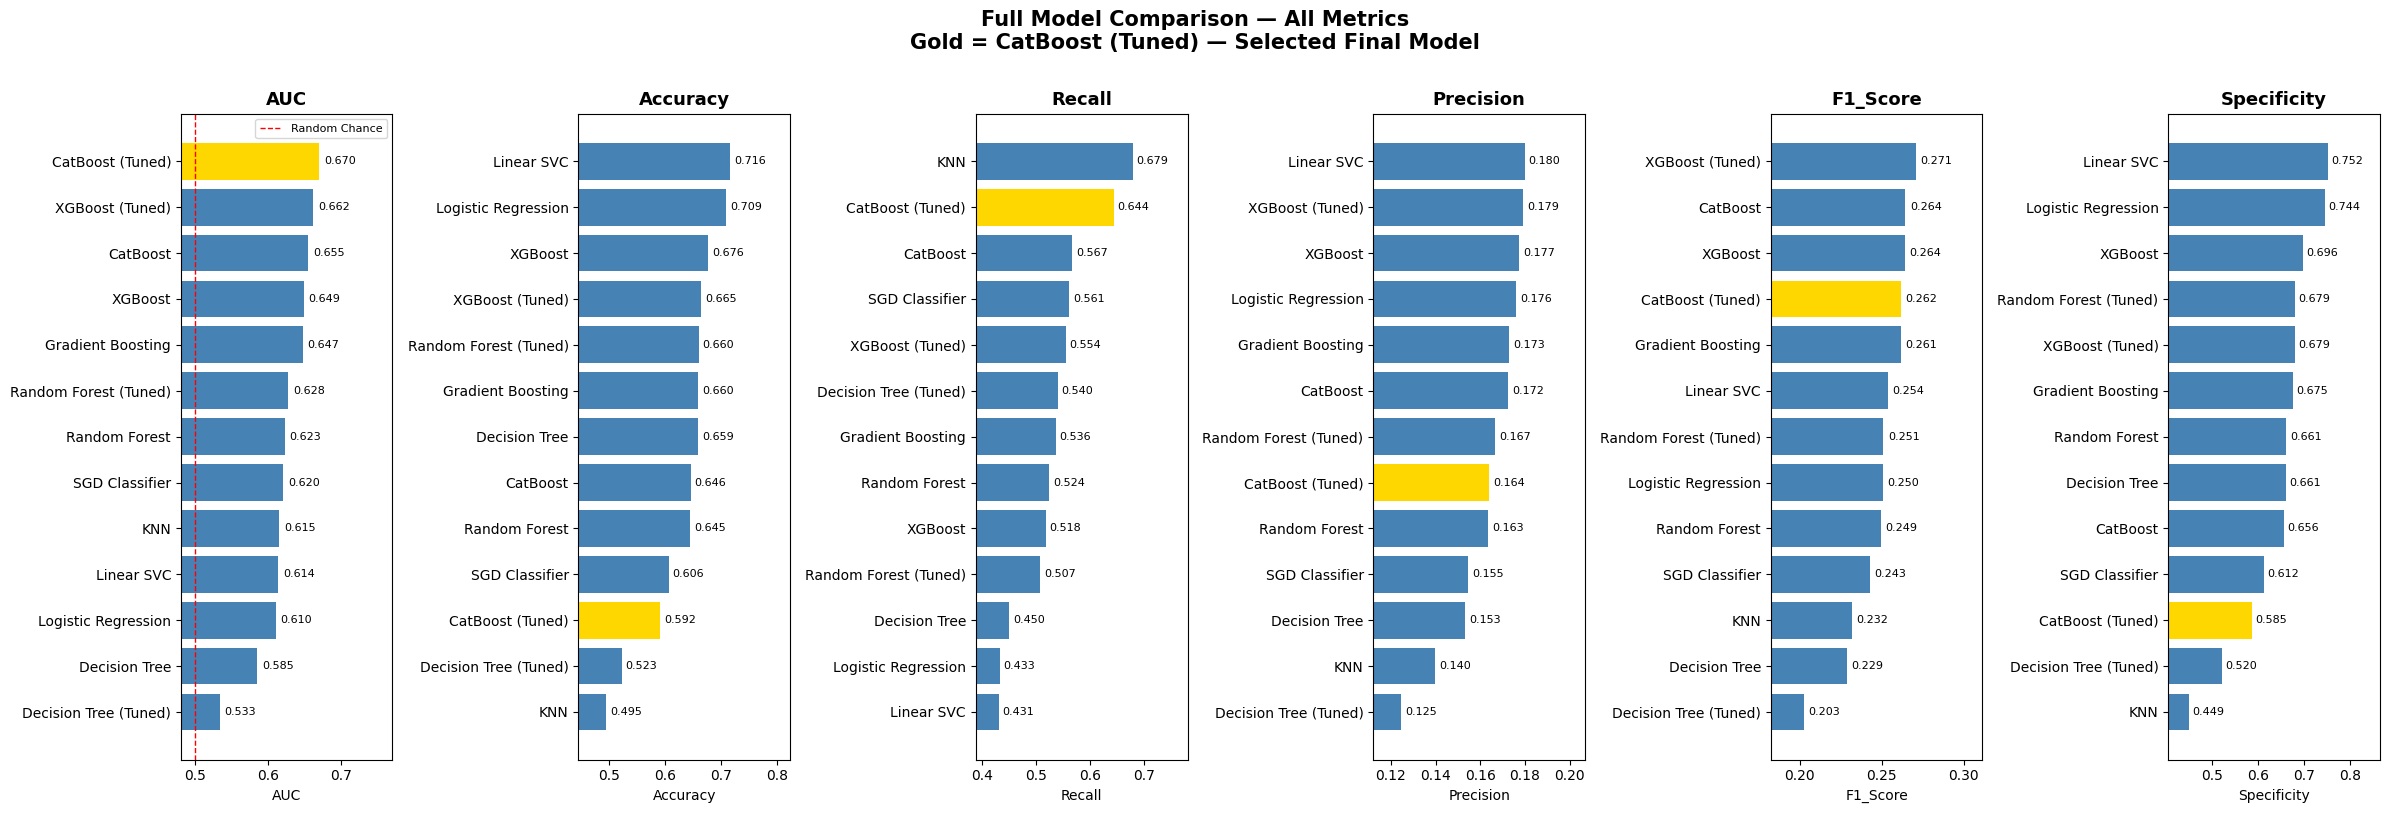

In [41]:
# ── 6. FULL METRICS BAR CHART — ALL MODELS ──
metrics = ['AUC', 'Accuracy', 'Recall', 'Precision', 'F1_Score', 'Specificity']
n_metrics = len(metrics)

fig, axes = plt.subplots(1, n_metrics, figsize=(24, 8))

for i, metric in enumerate(metrics):
    results_sorted = results_table.sort_values(metric, ascending=True)
    
    colors = ['gold' if 'CatBoost (Tuned)' in m else 'steelblue'
              for m in results_sorted['Model']]
    
    axes[i].barh(results_sorted['Model'], results_sorted[metric], color=colors)
    axes[i].set_title(f'{metric}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(metric)
    
    # Set x limits with some padding
    max_val = results_sorted[metric].max()
    min_val = results_sorted[metric].min()
    axes[i].set_xlim(max(0, min_val * 0.9), min(1.0, max_val * 1.15))
    
    # Add value labels
    for j, v in enumerate(results_sorted[metric]):
        axes[i].text(v + (max_val * 0.01), j, f'{v:.3f}',
                     va='center', fontsize=8)
    
    # Add random chance line only on AUC
    if metric == 'AUC':
        axes[i].axvline(0.5, color='red', linestyle='--', lw=1, label='Random Chance')
        axes[i].legend(fontsize=8)

plt.suptitle('Full Model Comparison — All Metrics\nGold = CatBoost (Tuned) — Selected Final Model',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

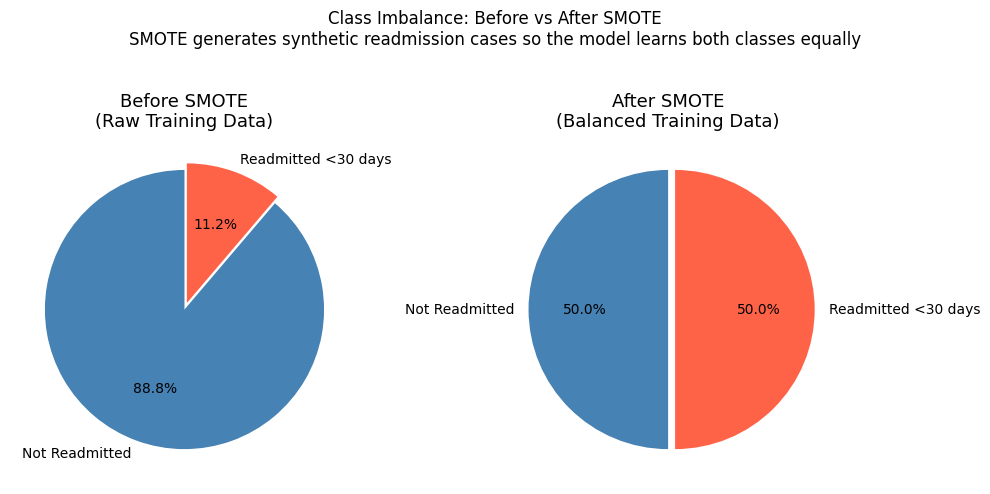

Before SMOTE — Not Readmitted: 61,861 | Readmitted: 7,823
After SMOTE  — Not Readmitted: 61,861 | Readmitted: 61,861


In [42]:
# ── 7. CLASS IMBALANCE — BEFORE & AFTER SMOTE ──
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Before SMOTE
before_counts = pd.Series(y_train).value_counts()
axes[0].pie(before_counts,
            labels=['Not Readmitted', 'Readmitted <30 days'],
            autopct='%1.1f%%',
            colors=['steelblue', 'tomato'],
            startangle=90,
            explode=(0, 0.05))
axes[0].set_title('Before SMOTE\n(Raw Training Data)', fontsize=13)

# After SMOTE
after_counts = pd.Series(y_train_res).value_counts()
axes[1].pie(after_counts,
            labels=['Not Readmitted', 'Readmitted <30 days'],
            autopct='%1.1f%%',
            colors=['steelblue', 'tomato'],
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title('After SMOTE\n(Balanced Training Data)', fontsize=13)

plt.suptitle('Class Imbalance: Before vs After SMOTE\nSMOTE generates synthetic readmission cases so the model learns both classes equally',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f"Before SMOTE — Not Readmitted: {before_counts[0]:,} | Readmitted: {before_counts[1]:,}")
print(f"After SMOTE  — Not Readmitted: {after_counts[0]:,} | Readmitted: {after_counts[1]:,}")

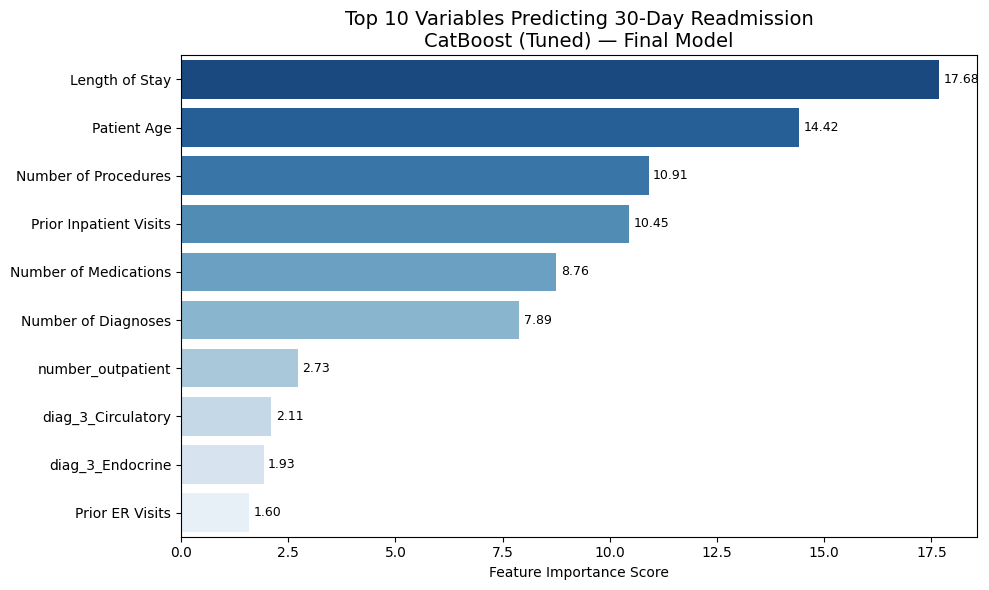

In [43]:
# ── 8. TOP 10 FEATURE IMPORTANCE — CLEAN FINAL CHART ──
feat_imp_final = pd.DataFrame({
    'feature': x_train.columns,
    'importance': catb_random.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False).head(10)

name_map = {
    'number_inpatient': 'Prior Inpatient Visits',
    'number_emergency': 'Prior ER Visits',
    'time_in_hospital': 'Length of Stay',
    'number_diagnoses': 'Number of Diagnoses',
    'num_medications': 'Number of Medications',
    'num_lab_procedures': 'Lab Procedures',
    'num_procedures': 'Number of Procedures',
    'age': 'Patient Age',
    'diabetesMed_Yes': 'On Diabetes Medication',
    'insulin_Steady': 'Insulin: Steady Dose',
    'insulin_Up': 'Insulin: Dose Increased',
    'change_Ch': 'Medication Change During Stay',
}
feat_imp_final['clean_name'] = feat_imp_final['feature'].map(
    lambda x: name_map.get(x, x)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feat_imp_final, x='importance', y='clean_name',
            palette='Blues_r', ax=ax)
plt.title('Top 10 Variables Predicting 30-Day Readmission\nCatBoost (Tuned) — Final Model',
          fontsize=14)
plt.xlabel('Feature Importance Score')
plt.ylabel('')

for p in ax.patches:
    width = p.get_width()
    y_pos = p.get_y() + p.get_height() / 2.
    ax.text(width + 0.1, y_pos, f'{width:.2f}',
            ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Fewest variables

n=  5 features → AUC: 0.614 | Recall: 0.448 | Accuracy: 0.689
n= 10 features → AUC: 0.613 | Recall: 0.508 | Accuracy: 0.643
n= 15 features → AUC: 0.616 | Recall: 0.501 | Accuracy: 0.650
n= 20 features → AUC: 0.618 | Recall: 0.549 | Accuracy: 0.620
n= 30 features → AUC: 0.626 | Recall: 0.600 | Accuracy: 0.591
n= 50 features → AUC: 0.645 | Recall: 0.547 | Accuracy: 0.652

  FEATURE REDUCTION RESULTS — Full Model vs Slim Models
  Full Model (220 features) → AUC: 0.670 | Recall: 0.644 | F1-Score: 0.262
 n_features   AUC  Accuracy  Recall  Precision  F1_Score  Specificity
          5 0.614     0.689   0.448      0.168     0.244        0.719
         10 0.613     0.643   0.508      0.159     0.242        0.660
         15 0.616     0.650   0.501      0.161     0.243        0.669
         20 0.618     0.620   0.549      0.158     0.245        0.629
         30 0.626     0.591   0.600      0.156     0.248        0.590
         50 0.645     0.652   0.547      0.171     0.261        0.665


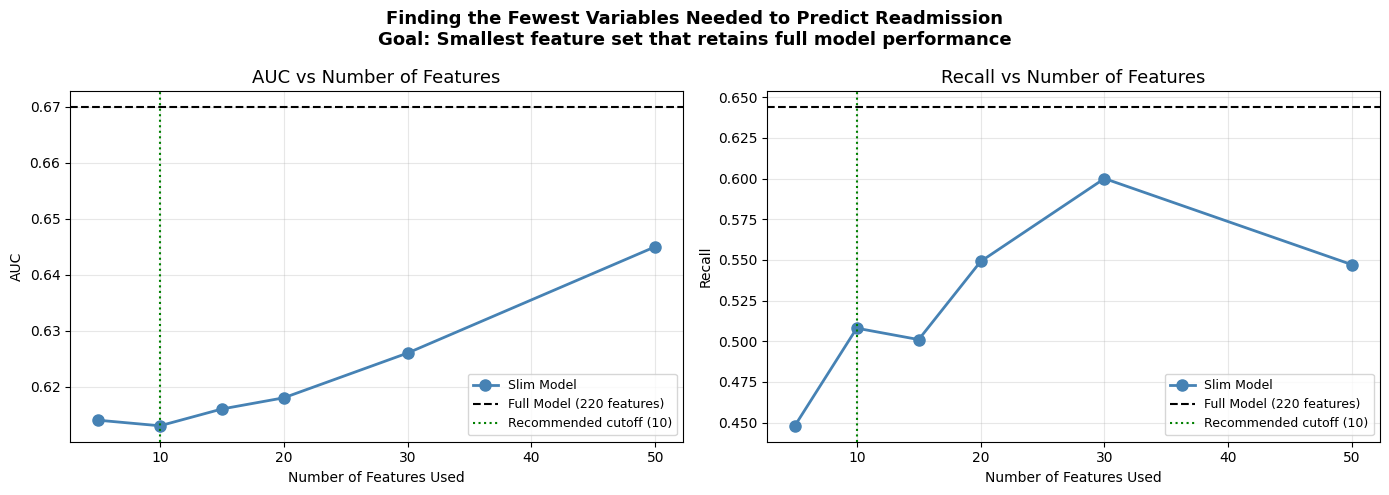

In [44]:
# ══════════════════════════════════════════════════════════════
# FEWEST VARIABLES — Identify Minimum Features Needed
# ══════════════════════════════════════════════════════════════

# Step 1: Get top features from CatBoost Tuned
feat_imp = pd.DataFrame({
    'feature': x_train.columns,
    'importance': catb_random.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

# Step 2: Test progressively fewer features to find the minimum
feature_counts = [5, 10, 15, 20, 30, 50]
slim_results = []

for n in feature_counts:
    top_n_features = feat_imp.head(n)['feature'].tolist()
    
    x_train_slim = x_train_res[top_n_features]
    x_valid_slim = x_valid[top_n_features]
    
    catb_slim = CatBoostClassifier(
        iterations=catb_random.best_params_['iterations'],
        depth=catb_random.best_params_['depth'],
        learning_rate=catb_random.best_params_['learning_rate'],
        random_state=111, verbose=0
    )
    catb_slim.fit(x_train_slim, y_train_res)
    
    slim_preds = catb_slim.predict_proba(x_valid_slim)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_valid, slim_preds)
    slim_thresh = thresholds[np.argmax(tpr - fpr)]
    
    auc   = roc_auc_score(y_valid, slim_preds)
    acc   = accuracy_score(y_valid, (slim_preds > slim_thresh))
    rec   = recall_score(y_valid, (slim_preds > slim_thresh))
    prec  = precision_score(y_valid, (slim_preds > slim_thresh))
    f1    = f1_score(y_valid, (slim_preds > slim_thresh))
    spec  = calc_specificity(y_valid, slim_preds, slim_thresh)
    
    slim_results.append({
        'n_features': n,
        'AUC': round(auc, 3),
        'Accuracy': round(acc, 3),
        'Recall': round(rec, 3),
        'Precision': round(prec, 3),
        'F1_Score': round(f1, 3),
        'Specificity': round(spec, 3)
    })
    print(f"n={n:3d} features → AUC: {auc:.3f} | Recall: {rec:.3f} | Accuracy: {acc:.3f}")

slim_df = pd.DataFrame(slim_results)

print("\n" + "=" * 70)
print("  FEATURE REDUCTION RESULTS — Full Model vs Slim Models")
print("=" * 70)
print(f"  Full Model ({x_train.shape[1]} features) → "
      f"AUC: {catb_hp_auc:.3f} | Recall: {catb_hp_recall:.3f} | F1-Score: {catb_hp_f1:.3f}")
print(slim_df.to_string(index=False))

# Step 3: Plot performance vs number of features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_to_plot = ['AUC', 'Recall']
colors = ['steelblue', 'steelblue']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    axes[i].plot(slim_df['n_features'], slim_df[metric],
                 marker='o', color=color, lw=2, markersize=8, label='Slim Model')
    
    # Full model reference line
    full_val = catb_hp_auc if metric == 'AUC' else catb_hp_recall
    axes[i].axhline(full_val, color='black', linestyle='--', lw=1.5,
                    label=f'Full Model ({x_train.shape[1]} features)')
    
    # Highlight the elbow point (10 features)
    axes[i].axvline(10, color='green', linestyle=':', lw=1.5, label='Recommended cutoff (10)')
    
    axes[i].set_title(f'{metric} vs Number of Features', fontsize=13)
    axes[i].set_xlabel('Number of Features Used')
    axes[i].set_ylabel(metric)
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('Finding the Fewest Variables Needed to Predict Readmission\n'
             'Goal: Smallest feature set that retains full model performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [45]:
# Step 4: Final slim model — retrain on top 10 and evaluate on test set
top_10_features = feat_imp.head(10)['feature'].tolist()

print("Top 10 Features Selected:")
for i, f in enumerate(top_10_features, 1):
    importance_val = feat_imp[feat_imp['feature'] == f]['importance'].values[0]
    print(f"  {i:2d}. {f:<45} (importance: {importance_val:.3f})")

x_train_slim = x_train_res[top_10_features]
x_valid_slim = x_valid[top_10_features]
x_test_slim  = x_test[top_10_features]

catb_final_slim = CatBoostClassifier(
    iterations=catb_random.best_params_['iterations'],
    depth=catb_random.best_params_['depth'],
    learning_rate=catb_random.best_params_['learning_rate'],
    random_state=111, verbose=0
)
catb_final_slim.fit(x_train_slim, y_train_res)

# Evaluate on test set
slim_test_preds = catb_final_slim.predict_proba(x_test_slim)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, slim_test_preds)
slim_test_thresh = thresholds[np.argmax(tpr - fpr)]

print("\n" + "=" * 55)
print("  SLIM MODEL — Test Set Results (Top 10 Features)")
print("=" * 55)
slim_test_auc, slim_test_acc, slim_test_recall, \
    slim_test_prec, slim_test_f1, slim_test_spec = print_report(y_test, slim_test_preds, slim_test_thresh)

print("\n" + "=" * 55)
print("  FULL vs SLIM MODEL COMPARISON (Test Set)")
print("=" * 55)
print(f"  {'Metric':<15} {'Full Model':>12} {'Slim (10 feat)':>15}")
print(f"  {'-'*42}")
print(f"  {'AUC':<15} {catb_hp_auc:>12.3f} {slim_test_auc:>15.3f}")
print(f"  {'Accuracy':<15} {catb_hp_accuracy:>12.3f} {slim_test_acc:>15.3f}")
print(f"  {'Recall':<15} {catb_hp_recall:>12.3f} {slim_test_recall:>15.3f}")
print(f"  {'Precision':<15} {catb_hp_precision:>12.3f} {slim_test_prec:>15.3f}")
print(f"  {'F1-Score':<15} {catb_hp_f1:>12.3f} {slim_test_f1:>15.3f}")
print(f"  {'Specificity':<15} {catb_hp_specificity:>12.3f} {slim_test_spec:>15.3f}")
print(f"  {'# Features':<15} {x_train.shape[1]:>12} {'10':>15}")

Top 10 Features Selected:
   1. time_in_hospital                              (importance: 17.679)
   2. age                                           (importance: 14.420)
   3. num_procedures                                (importance: 10.906)
   4. number_inpatient                              (importance: 10.454)
   5. num_medications                               (importance: 8.756)
   6. number_diagnoses                              (importance: 7.890)
   7. number_outpatient                             (importance: 2.728)
   8. diag_3_Circulatory                            (importance: 2.109)
   9. diag_3_Endocrine                              (importance: 1.930)
  10. number_emergency                              (importance: 1.595)

  SLIM MODEL — Test Set Results (Top 10 Features)
AUC:0.621
Accuracy:0.667
recall:0.484
precision:0.165
F1 Score:0.246
specificity:0.691
prevalence:0.112

  FULL vs SLIM MODEL COMPARISON (Test Set)
  Metric            Full Model  Slim (10 feat)
  --

## CLUSTERING — K-Means Patient Risk Groups

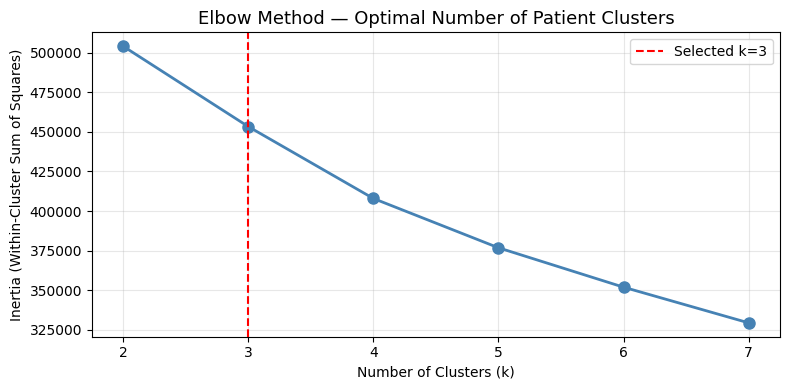

In [46]:
# ══════════════════════════════════════════════════════════════
# CLUSTERING — K-Means Patient Risk Groups
# ══════════════════════════════════════════════════════════════
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Use top 10 features on unbalanced training data (real distribution)
x_train_cluster = x_train[top_10_features]

# Step 1: Find optimal number of clusters using elbow method
inertia = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_train_cluster)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue', lw=2, markersize=8)
plt.axvline(3, color='red', linestyle='--', lw=1.5, label='Selected k=3')
plt.title('Elbow Method — Optimal Number of Patient Clusters', fontsize=13)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# Step 2: Fit final K-Means with k=3 (Low / Medium / High risk)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(x_train_cluster)

# Step 3: Assign meaningful labels based on readmission rate per cluster
cluster_df = pd.DataFrame({
    'cluster': clusters,
    'readmitted': y_train.values
})
cluster_readmit_rate = cluster_df.groupby('cluster')['readmitted'].mean()

# Sort clusters by readmission rate and assign labels
sorted_clusters = cluster_readmit_rate.sort_values().index.tolist()
cluster_label_map = {
    sorted_clusters[0]: 'Low Risk',
    sorted_clusters[1]: 'Medium Risk',
    sorted_clusters[2]: 'High Risk'
}
cluster_df['risk_group'] = cluster_df['cluster'].map(cluster_label_map)

cluster_summary = cluster_df.groupby('risk_group').agg(
    patient_count=('readmitted', 'count'),
    readmission_rate=('readmitted', 'mean')
).reset_index()
cluster_summary['readmission_rate_%'] = (cluster_summary['readmission_rate'] * 100).round(1)

print("=" * 55)
print("  CLUSTER SUMMARY — Patient Risk Groups")
print("=" * 55)
print(cluster_summary[['risk_group', 'patient_count', 'readmission_rate_%']].to_string(index=False))

  CLUSTER SUMMARY — Patient Risk Groups
 risk_group  patient_count  readmission_rate_%
  High Risk          16295                12.6
   Low Risk          20603                 8.2
Medium Risk          32786                12.4


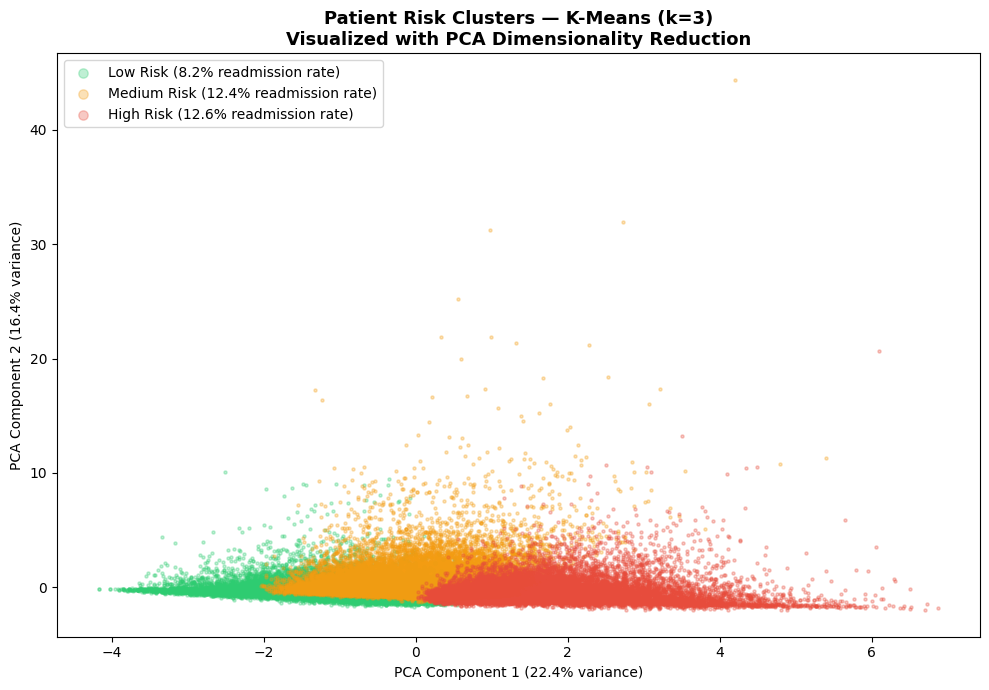

In [48]:
# Step 4: Visualize clusters with PCA (reduce to 2D for plotting)
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(x_train_cluster)

color_map = {'Low Risk': '#2ecc71', 'Medium Risk': '#f39c12', 'High Risk': '#e74c3c'}
cluster_colors = cluster_df['risk_group'].map(color_map)

plt.figure(figsize=(10, 7))
for group, color in color_map.items():
    mask = cluster_df['risk_group'] == group
    rate = cluster_summary[cluster_summary['risk_group'] == group]['readmission_rate_%'].values[0]
    plt.scatter(x_pca[mask, 0], x_pca[mask, 1],
                c=color, alpha=0.3, s=5,
                label=f'{group} ({rate}% readmission rate)')

plt.title('Patient Risk Clusters — K-Means (k=3)\nVisualized with PCA Dimensionality Reduction',
          fontsize=13, fontweight='bold')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(fontsize=10, markerscale=3)
plt.tight_layout()
plt.show()


  CLUSTER PROFILES — Average Feature Values by Risk Group
             time_in_hospital   age  num_procedures  number_inpatient  num_medications
risk_group                                                                            
High Risk                1.10  0.03            0.99              0.02             1.10
Low Risk                -0.47 -0.53           -0.16             -0.24            -0.52
Medium Risk             -0.25  0.31           -0.39              0.14            -0.22


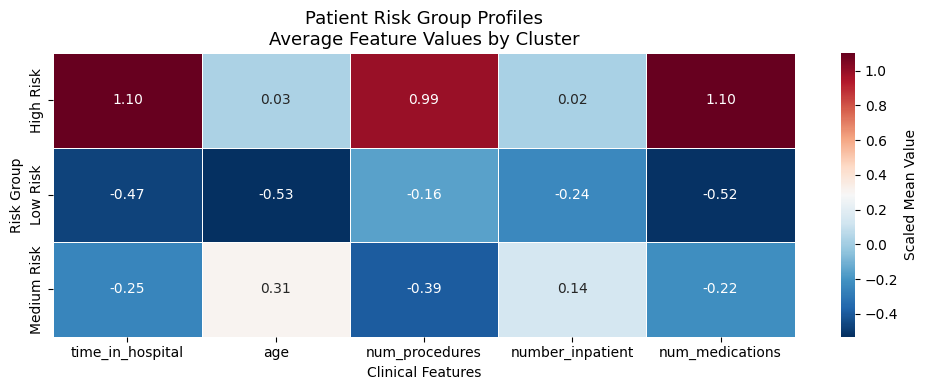

In [49]:
# Step 5: Cluster profile — what does each risk group look like clinically
cluster_profile = x_train[top_10_features].copy()
cluster_profile['risk_group'] = cluster_df['risk_group'].values
cluster_profile['readmitted'] = y_train.values

# Mean values per cluster for top 5 numeric features
numeric_top5 = [f for f in top_10_features
                if f in ['time_in_hospital', 'number_inpatient', 'number_emergency',
                         'number_diagnoses', 'num_medications', 'age',
                         'num_procedures', 'num_lab_procedures']][:5]

profile_summary = cluster_profile.groupby('risk_group')[numeric_top5].mean().round(2)

print("\n" + "=" * 70)
print("  CLUSTER PROFILES — Average Feature Values by Risk Group")
print("=" * 70)
print(profile_summary.to_string())

# Heatmap of cluster profiles
plt.figure(figsize=(10, 4))
sns.heatmap(profile_summary, annot=True, fmt='.2f', cmap='RdBu_r',
            linewidths=0.5, cbar_kws={'label': 'Scaled Mean Value'})
plt.title('Patient Risk Group Profiles\nAverage Feature Values by Cluster', fontsize=13)
plt.xlabel('Clinical Features')
plt.ylabel('Risk Group')
plt.tight_layout()
plt.show()

## MULTILEVEL LINEAR MODEL

In [50]:
# ══════════════════════════════════════════════════════════════
# MULTILEVEL LINEAR MODEL
# Accounts for the fact that patients are nested within age groups
# — patients of the same age share underlying risk characteristics
# ══════════════════════════════════════════════════════════════
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Build a clean dataframe with the variables we need
mlm_df = df_with_payer[[
    'number_inpatient', 'time_in_hospital',
    'number_diagnoses', 'num_medications',
    'number_emergency', 'age', 'readmitted'
]].dropna().copy()

# Create age group as the grouping variable (level 2)
# Patients are nested WITHIN age groups
mlm_df['age_group'] = pd.cut(
    mlm_df['age'],
    bins=[-1, 2, 4, 6, 9],
    labels=['Young (0-30)', 'Middle (40-60)', 'Senior (60-70)', 'Elderly (70+)']
)
mlm_df = mlm_df.dropna(subset=['age_group'])

print(f"MLM dataset shape: {mlm_df.shape}")
print(f"\nSample counts by age group:")
print(mlm_df['age_group'].value_counts().sort_index())

MLM dataset shape: (99493, 8)

Sample counts by age group:
age_group
Young (0-30)       2453
Middle (40-60)    13164
Senior (60-70)    38883
Elderly (70+)     44993
Name: count, dtype: int64


In [51]:
# Fit the Multilevel Linear Model
# Fixed effects: number_inpatient, time_in_hospital, number_diagnoses
# Random effect: intercept varies by age_group
# This means: the baseline readmission risk differs across age groups,
# but the effect of each clinical variable is assumed consistent

mlm_model = smf.mixedlm(
    "readmitted ~ number_inpatient + time_in_hospital + number_diagnoses + num_medications + number_emergency",
    data=mlm_df,
    groups=mlm_df['age_group']
)

mlm_result = mlm_model.fit(method='bfgs')
print(mlm_result.summary())

          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: readmitted 
No. Observations:  99493   Method:             REML       
No. Groups:        4       Scale:              0.0967     
Min. group size:   2453    Log-Likelihood:     -25001.2975
Max. group size:   44993   Converged:          No         
Mean group size:   24873.2                                
----------------------------------------------------------
                 Coef. Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        0.039    0.151  0.261 0.794 -0.256  0.335
number_inpatient 0.039    0.001 47.786 0.000  0.037  0.040
time_in_hospital 0.002    0.000  5.560 0.000  0.001  0.003
number_diagnoses 0.004    0.001  6.363 0.000  0.002  0.005
num_medications  0.001    0.000  4.068 0.000  0.000  0.001
number_emergency 0.006    0.001  5.903 0.000  0.004  0.009
Group Var        0.091                                    



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 3.093924
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnin

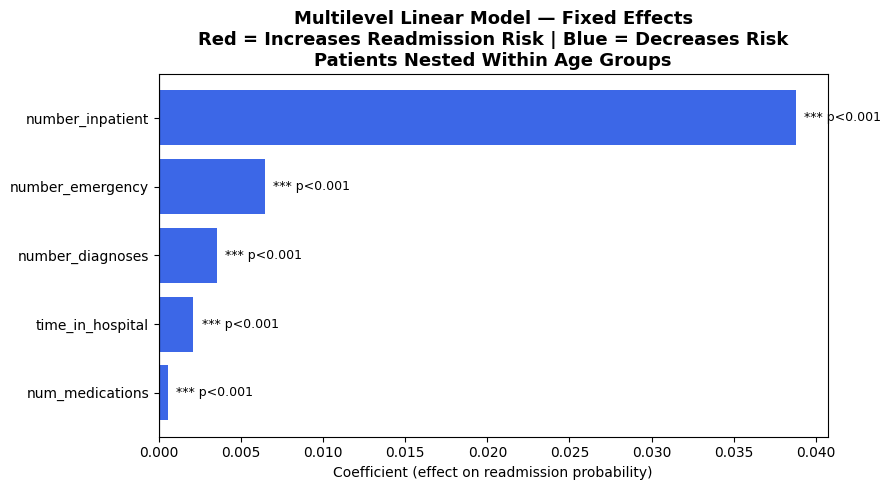


  MLM FIXED EFFECTS — CLINICAL INTERPRETATION
  number_inpatient               ↑ INCREASES readmission risk  *** p<0.001
  number_emergency               ↑ INCREASES readmission risk  *** p<0.001
  number_diagnoses               ↑ INCREASES readmission risk  *** p<0.001
  time_in_hospital               ↑ INCREASES readmission risk  *** p<0.001
  num_medications                ↑ INCREASES readmission risk  *** p<0.001


In [52]:
# Extract and visualize fixed effects coefficients
mlm_coef = pd.DataFrame({
    'variable': mlm_result.fe_params.index,
    'coefficient': mlm_result.fe_params.values,
    'p_value': mlm_result.pvalues[mlm_result.fe_params.index].values  # align to fixed effects only
})

mlm_coef = mlm_coef[mlm_coef['variable'] != 'Intercept']
mlm_coef['significant'] = mlm_coef['p_value'].apply(
    lambda p: '*** p<0.001' if p < 0.001 else ('** p<0.01' if p < 0.01 else ('* p<0.05' if p < 0.05 else 'n.s.'))
)
mlm_coef = mlm_coef.sort_values('coefficient', ascending=True)

plt.figure(figsize=(9, 5))
colors = ["#3c67e7" if c > 0 else "#db3434" for c in mlm_coef['coefficient']]
plt.barh(mlm_coef['variable'], mlm_coef['coefficient'], color=colors)

for i, (_, row) in enumerate(mlm_coef.iterrows()):
    plt.text(row['coefficient'] + 0.0005, i,
             row['significant'], va='center', fontsize=9)

plt.axvline(0, color='black', lw=0.8)
plt.title('Multilevel Linear Model — Fixed Effects\n'
          'Red = Increases Readmission Risk | Blue = Decreases Risk\n'
          'Patients Nested Within Age Groups',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient (effect on readmission probability)')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("  MLM FIXED EFFECTS — CLINICAL INTERPRETATION")
print("=" * 60)
for _, row in mlm_coef.sort_values('coefficient', ascending=False).iterrows():
    direction = "↑ INCREASES" if row['coefficient'] > 0 else "↓ DECREASES"
    print(f"  {row['variable']:<30} {direction} readmission risk  {row['significant']}")

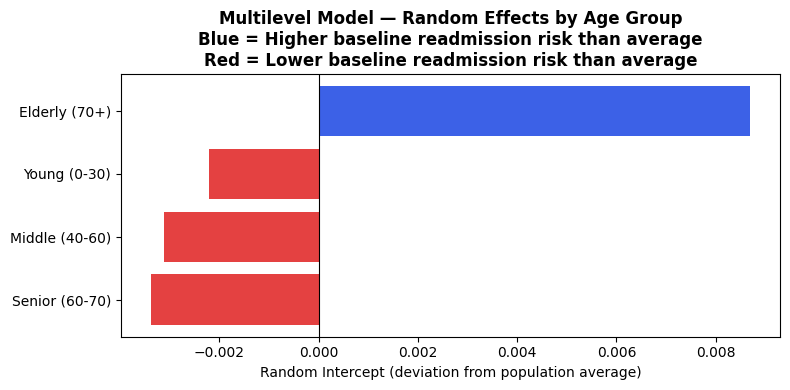

In [53]:
# Visualize random effects — how much baseline risk differs by age group
random_effects = mlm_result.random_effects
re_df = pd.DataFrame({
    'age_group': list(random_effects.keys()),
    'random_intercept': [v.values[0] for v in random_effects.values()]
}).sort_values('random_intercept')

plt.figure(figsize=(8, 4))
colors = ["#3c61e7" if v > 0 else "#e44141" for v in re_df['random_intercept']]
plt.barh(re_df['age_group'], re_df['random_intercept'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('Multilevel Model — Random Effects by Age Group\n'
          'Blue = Higher baseline readmission risk than average\n'
          'Red = Lower baseline readmission risk than average',
          fontsize=12, fontweight='bold')
plt.xlabel('Random Intercept (deviation from population average)')
plt.tight_layout()
plt.show()